In [1]:
import numpy as np
import pandas as pd
import datetime
import random

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import *
import seaborn as sns

import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

In [2]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)

2.20.0


In [3]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.3 MB/s eta 0:00:00


In [4]:
import keras
from keras_tuner import RandomSearch
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import AdamW
from keras import layers

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
np.random.seed(871)

## Data set creations

In [7]:
df_Ask = pd.read_csv("EURGBP_15 Mins_Ask_2024.05.09_2026.05.09.csv")
df_Bid = pd.read_csv("EURGBP_15 Mins_Bid_2024.05.09_2026.05.09.csv")

In [8]:
df_Bid.head(3)

,Time (EET),Open,High,Low,Close,Volume
0,2024.05.09 00:00:00,0.85990,0.85991,0.85875,0.85989,410.97
1,2024.05.09 00:15:00,0.85989,0.86002,0.85983,0.85986,454.65
2,2024.05.09 00:30:00,0.85983,0.85990,0.85979,0.85985,592.35


In [9]:
df_Ask.head(3)

,Time (EET),Open,High,Low,Close,Volume
0,2024.05.09 00:00:00,0.86019,0.86155,0.86011,0.86042,399.04
1,2024.05.09 00:15:00,0.86041,0.86045,0.86012,0.86012,434.33
2,2024.05.09 00:30:00,0.86013,0.86023,0.85995,0.86018,625.03


In [10]:
data = df_Bid.merge(df_Ask, left_on = 'Time (EET)', right_on='Time (EET)', how= 'outer')
data.columns = ['EET_time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                   'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']
data

,EET_time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask
0,2024.05.09 00:00:00,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04
1,2024.05.09 00:15:00,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33
2,2024.05.09 00:30:00,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03
3,2024.05.09 00:45:00,0.85986,0.86008,0.85985,0.86007,506.77,0.86019,0.86033,0.86015,0.86027,431.40
4,2024.05.09 01:00:00,0.86004,0.86010,0.85990,0.86009,223.77,0.86028,0.86028,0.86011,0.86020,219.30
...,...,...,...,...,...,...,...,...,...,...,...
49803,2026.05.08 22:45:00,0.86454,0.86457,0.86433,0.86436,846.78,0.86460,0.86465,0.86441,0.86443,831.49
49804,2026.05.08 23:00:00,0.86436,0.86437,0.86419,0.86436,631.34,0.86444,0.86445,0.86427,0.86444,701.81
49805,2026.05.08 23:15:00,0.86438,0.86451,0.86427,0.86430,357.51,0.86445,0.86459,0.86437,0.86438,450.52
49806,2026.05.08 23:30:00,0.86428,0.86467,0.86428,0.86454,808.64,0.86439,0.86476,0.86438,0.86466,765.78


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EET_time    49808 non-null  object 
 1   Open_Bid    49808 non-null  float64
 2   High_Bid    49808 non-null  float64
 3   Low_Bid     49808 non-null  float64
 4   Close_Bid   49808 non-null  float64
 5   Volume_Bid  49808 non-null  float64
 6   Open_Ask    49808 non-null  float64
 7   High_Ask    49808 non-null  float64
 8   Low_Ask     49808 non-null  float64
 9   Close_Ask   49808 non-null  float64
 10  Volume_Ask  49808 non-null  float64
dtypes: float64(10), object(1)
memory usage: 4.2+ MB


### Creating Data Deltas

In [12]:
# Signed bid-ask volume imbalance
data["Volume_Delta"] = data["Volume_Ask"] - data["Volume_Bid"]
# Absolute volume imbalance magnitude
data["Volume_Delta_abs"] = (data["Volume_Ask"] - data["Volume_Bid"]).abs()
# Opening spread (liquidity at session start)
data["Open_Delta"] = data["Open_Ask"] - data["Open_Bid"]
# Spread at price high (volatility indicator)
data["High_Delta"] = data["High_Ask"] - data["High_Bid"]
# Spread at price low (downside liquidity)
data["Low_Delta"] = data["Low_Ask"] - data["Low_Bid"]
# Closing spread (end-of-session transaction cost)
data["Close_Delta"] = data["Close_Ask"] - data["Close_Bid"]

In [13]:
data.head(3)

,EET_time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
0,2024.05.09 00:00:00,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,-11.93,11.93,0.00029,0.00164,0.00136,0.00053
1,2024.05.09 00:15:00,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,-20.32,20.32,0.00052,0.00043,0.00029,0.00026
2,2024.05.09 00:30:00,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,32.68,32.68,0.00030,0.00033,0.00016,0.00033


In [14]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
count,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000
mean,0.853783,0.853967,0.853604,0.853785,1120.336142,0.853894,0.854074,0.853712,0.853891,1125.074126,4.737984,93.569698,0.000111,0.000107,0.000108,0.000106
std,0.015914,0.015912,0.015917,0.015914,974.492666,0.015909,0.015908,0.015912,0.015910,979.642321,155.797097,124.658414,0.000176,0.000159,0.000163,0.000134
min,0.822380,0.822820,0.821980,0.822370,0.000000,0.822470,0.822910,0.822270,0.822460,0.000000,-2319.770000,0.000000,0.000030,0.000010,0.000040,0.000030
25%,0.840400,0.840570,0.840240,0.840400,495.982500,0.840518,0.840670,0.840330,0.840510,500.100000,-46.762500,20.050000,0.000060,0.000060,0.000060,0.000060
50%,0.853710,0.853900,0.853510,0.853715,901.285000,0.853850,0.854030,0.853640,0.853855,903.515000,3.335000,52.435000,0.000080,0.000070,0.000070,0.000080
75%,0.867820,0.868010,0.867660,0.867820,1450.170000,0.867920,0.868110,0.867760,0.867920,1457.182500,58.142500,117.260000,0.000090,0.000090,0.000090,0.000090
max,0.886380,0.886510,0.885810,0.886410,15866.280000,0.886420,0.886600,0.885880,0.886450,16541.130000,2239.220000,2319.770000,0.003420,0.003120,0.003040,0.002930


In [15]:
data.shape

(49808, 17)

In [16]:
data['EET_time_T'] = pd.to_datetime(data['EET_time'], utc= True)
data=data.drop(['EET_time'],axis=1)
data.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,EET_time_T
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,-11.93,11.93,0.00029,0.00164,0.00136,0.00053,2024-05-09 00:00:00+00:00
1,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,-20.32,20.32,0.00052,0.00043,0.00029,0.00026,2024-05-09 00:15:00+00:00
2,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,32.68,32.68,0.00030,0.00033,0.00016,0.00033,2024-05-09 00:30:00+00:00


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Open_Bid          49808 non-null  float64            
 1   High_Bid          49808 non-null  float64            
 2   Low_Bid           49808 non-null  float64            
 3   Close_Bid         49808 non-null  float64            
 4   Volume_Bid        49808 non-null  float64            
 5   Open_Ask          49808 non-null  float64            
 6   High_Ask          49808 non-null  float64            
 7   Low_Ask           49808 non-null  float64            
 8   Close_Ask         49808 non-null  float64            
 9   Volume_Ask        49808 non-null  float64            
 10  Volume_Delta      49808 non-null  float64            
 11  Volume_Delta_abs  49808 non-null  float64            
 12  Open_Delta        49808 non-null  float64            
 13  H

### Data Visualisation

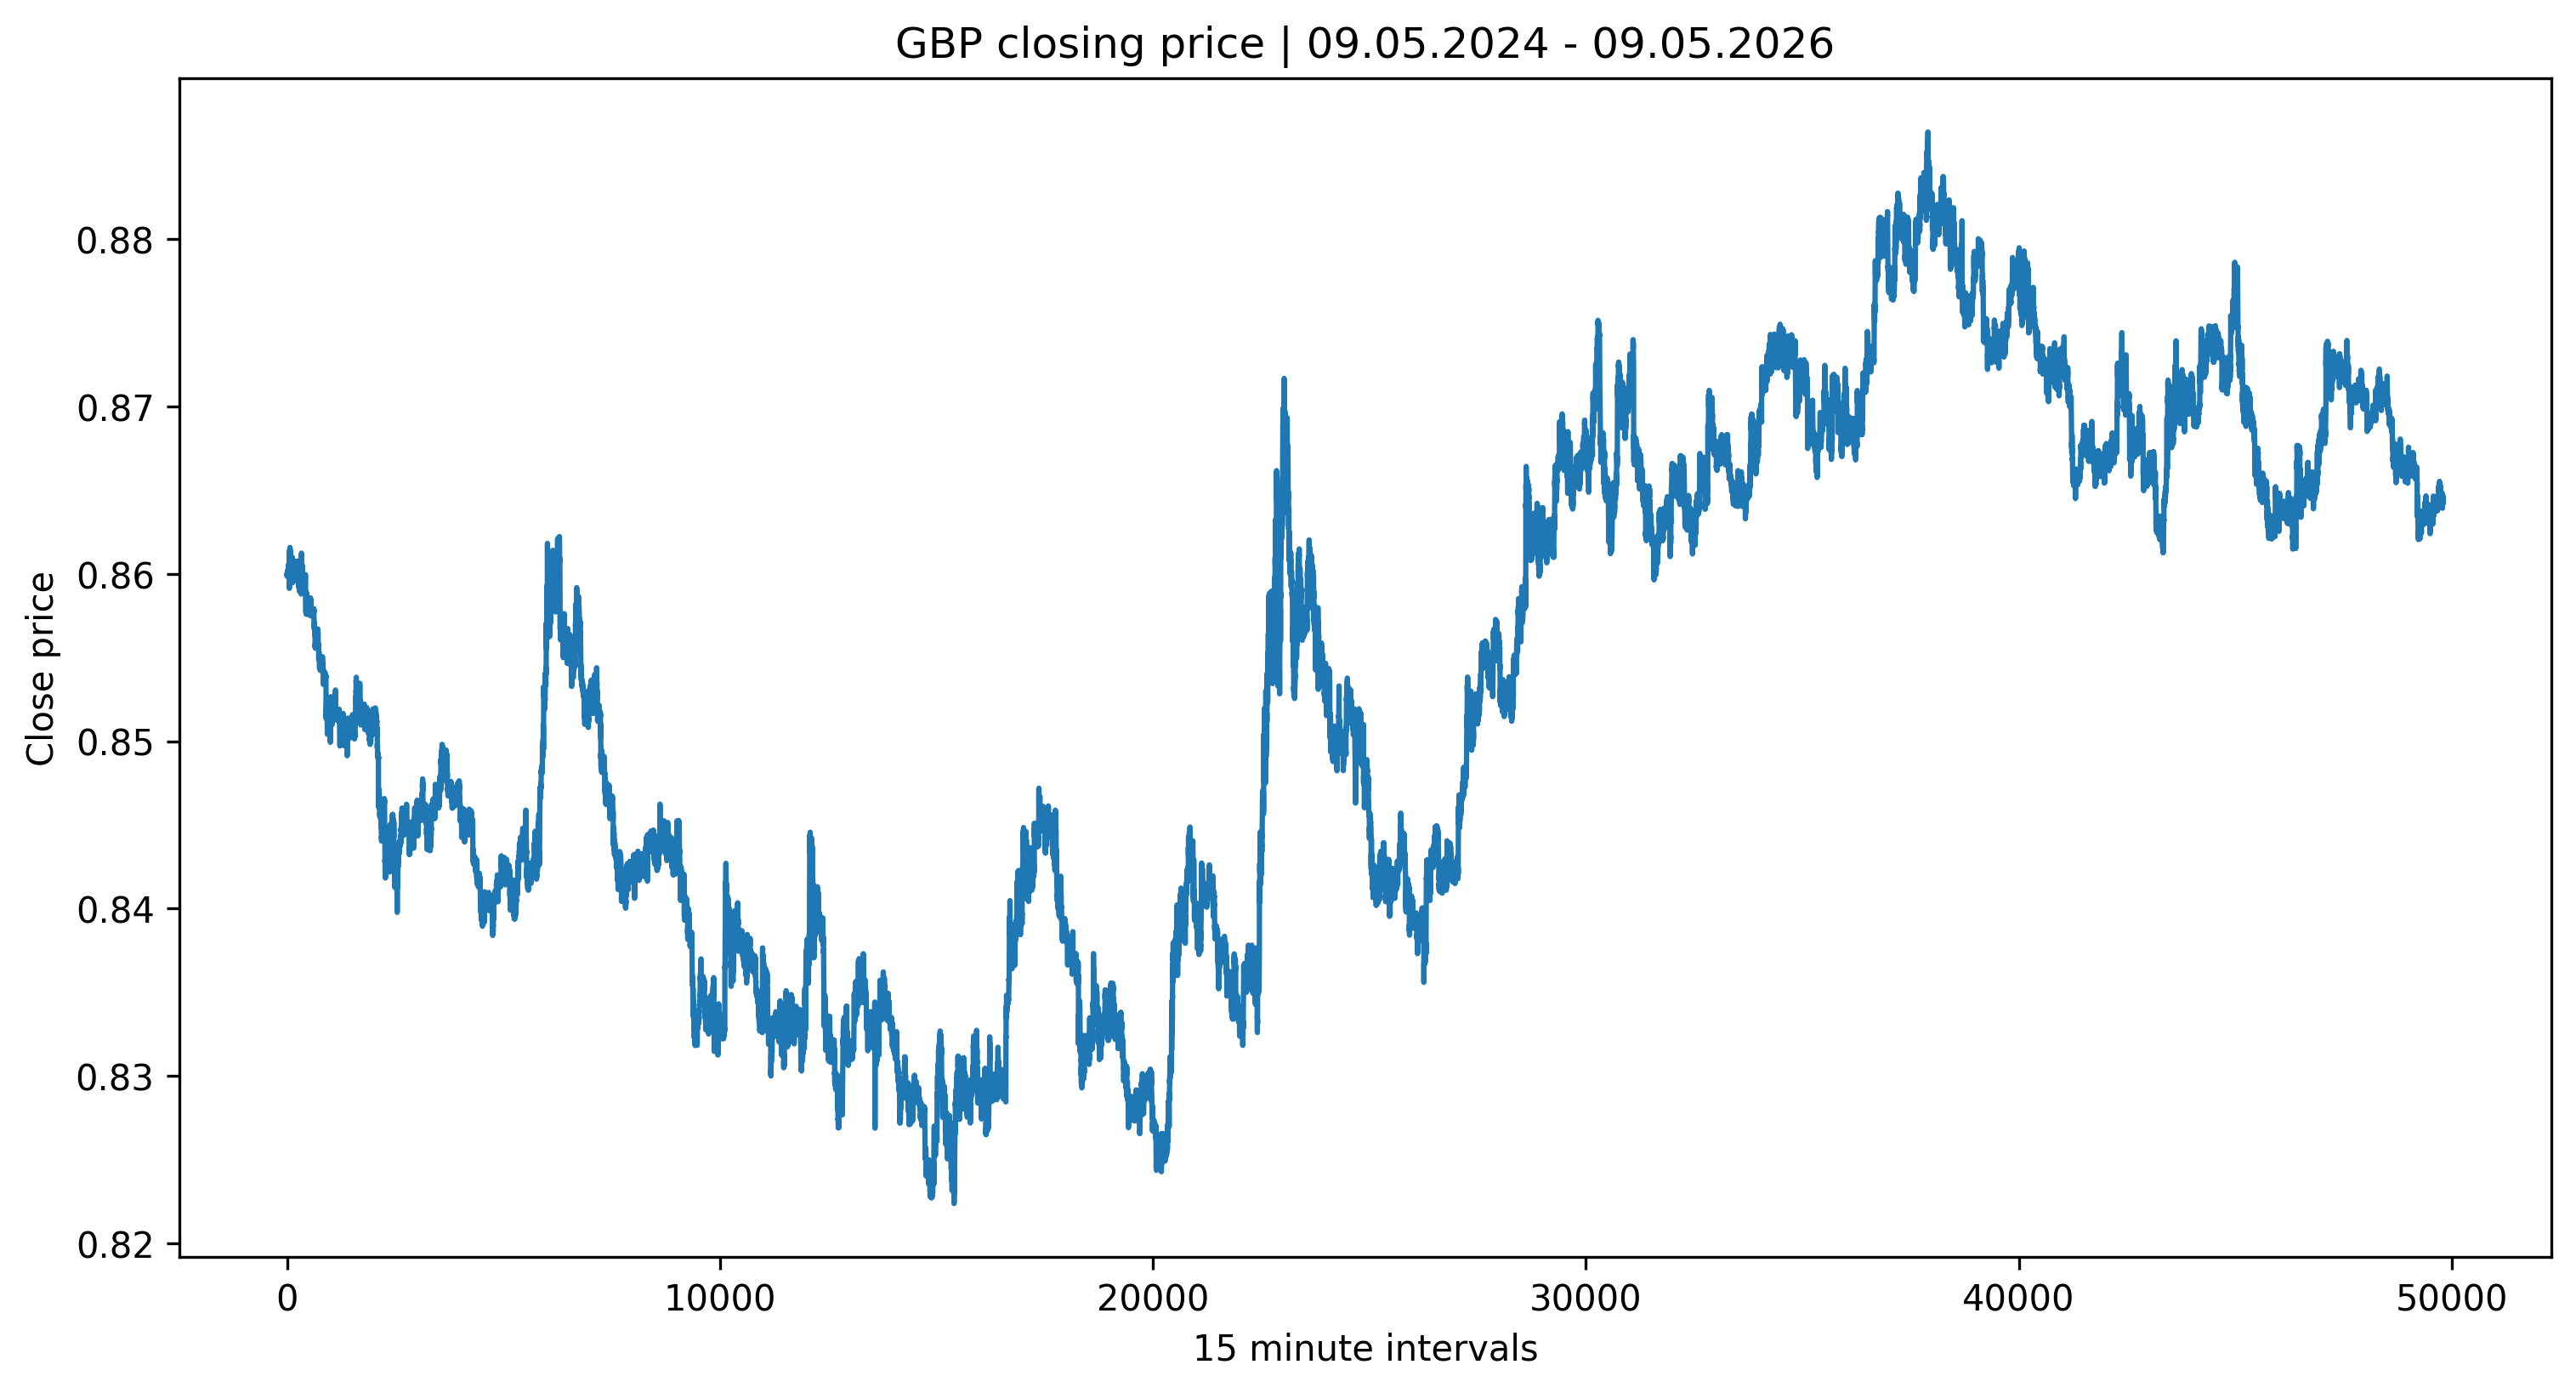

In [18]:
plt.figure(figsize=(12,6), dpi=300)
plt.plot(data['Close_Bid'])
plt.title('GBP closing price | 09.05.2024 - 09.05.2026')
plt.xlabel('15 minute intervals')
plt.ylabel('Close price')
plt.show()

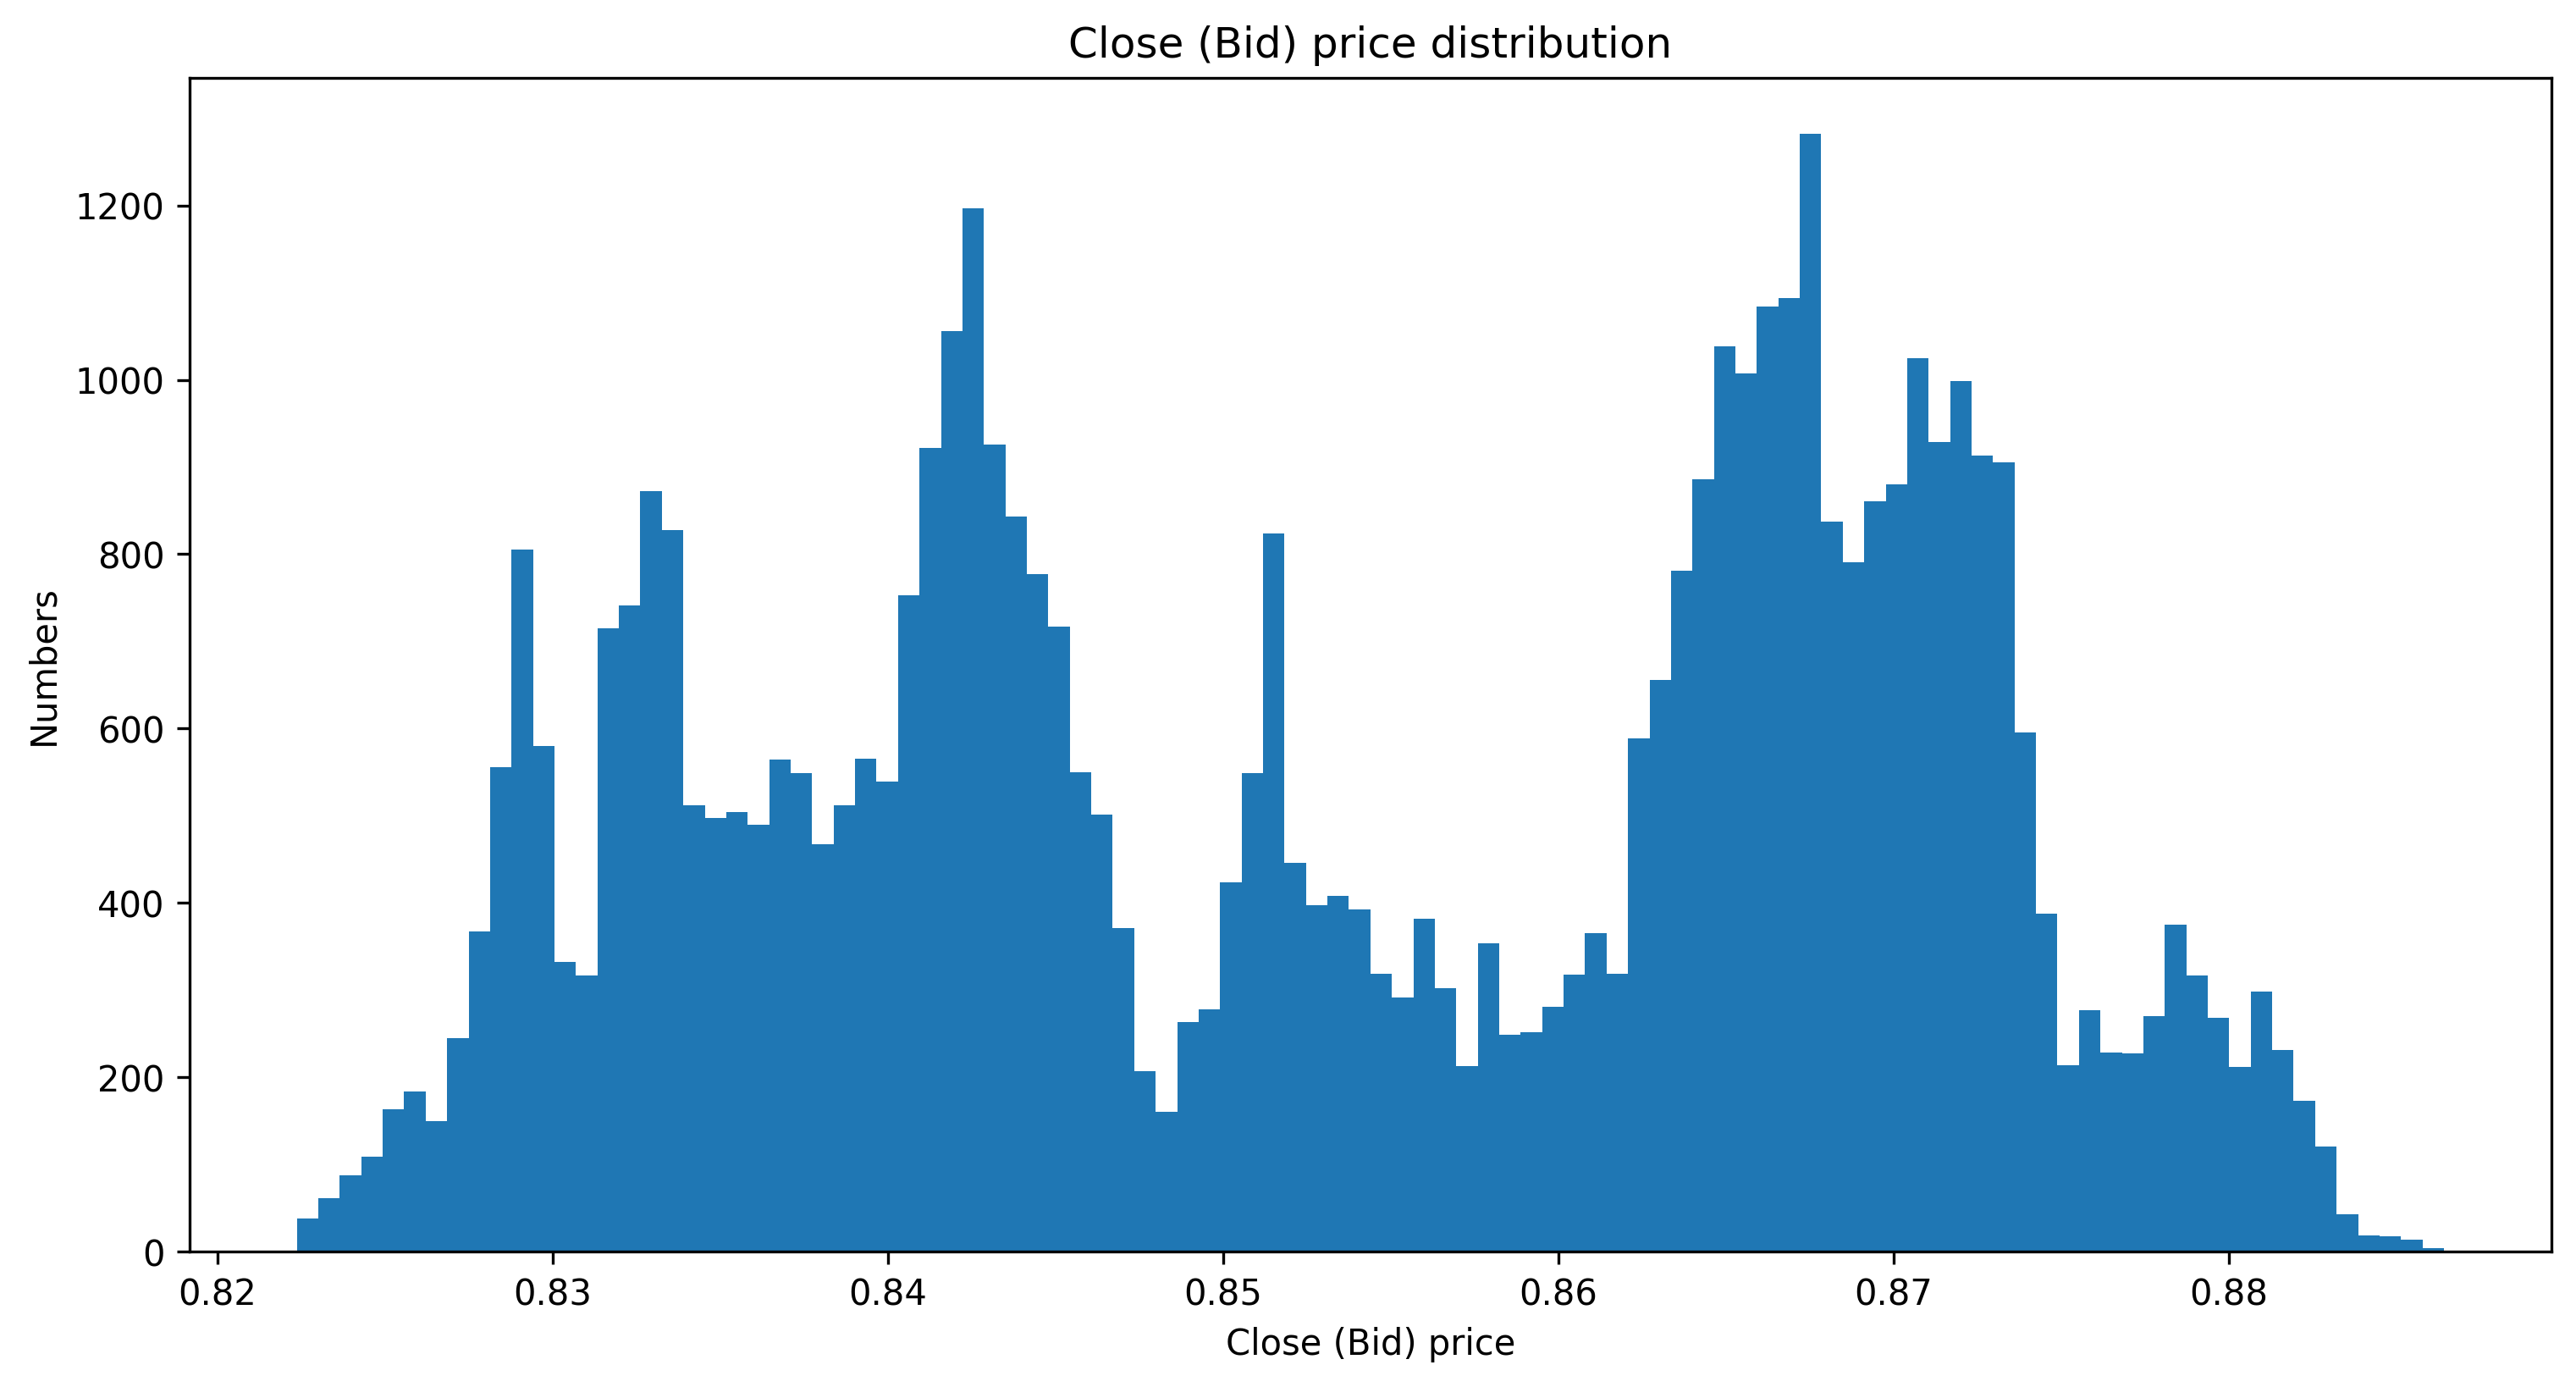

In [19]:
plt.figure(figsize=(12,6), dpi=300)
plt.hist(data['Close_Bid'], bins=100)
plt.title('Close (Bid) price distribution')
plt.ylabel('Numbers')
plt.xlabel('Close (Bid) price')
plt.show()

<Figure size 3600x1800 with 0 Axes>

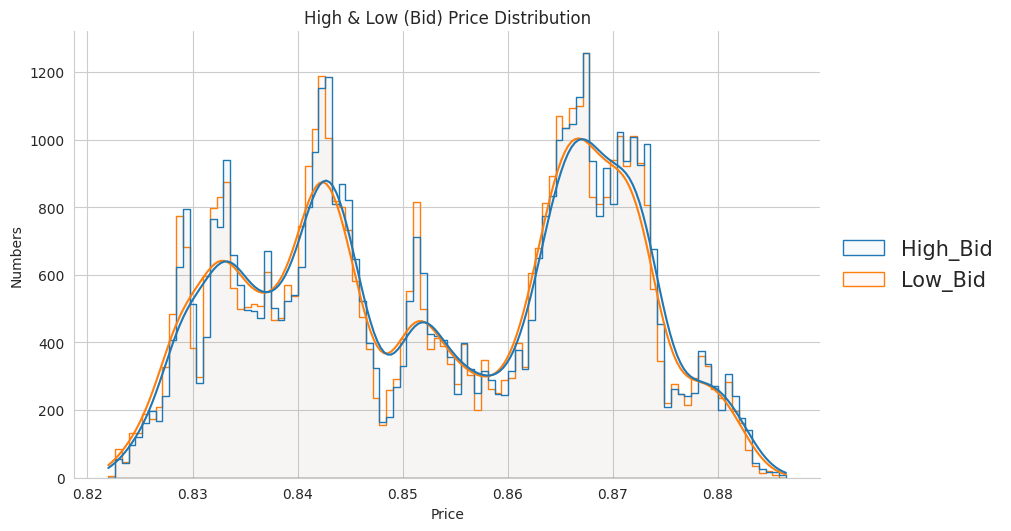

In [20]:
fig = plt.figure(figsize=(12, 6), dpi=300)
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 15.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']],
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price')
plt.ylabel('Numbers')
plt.show();

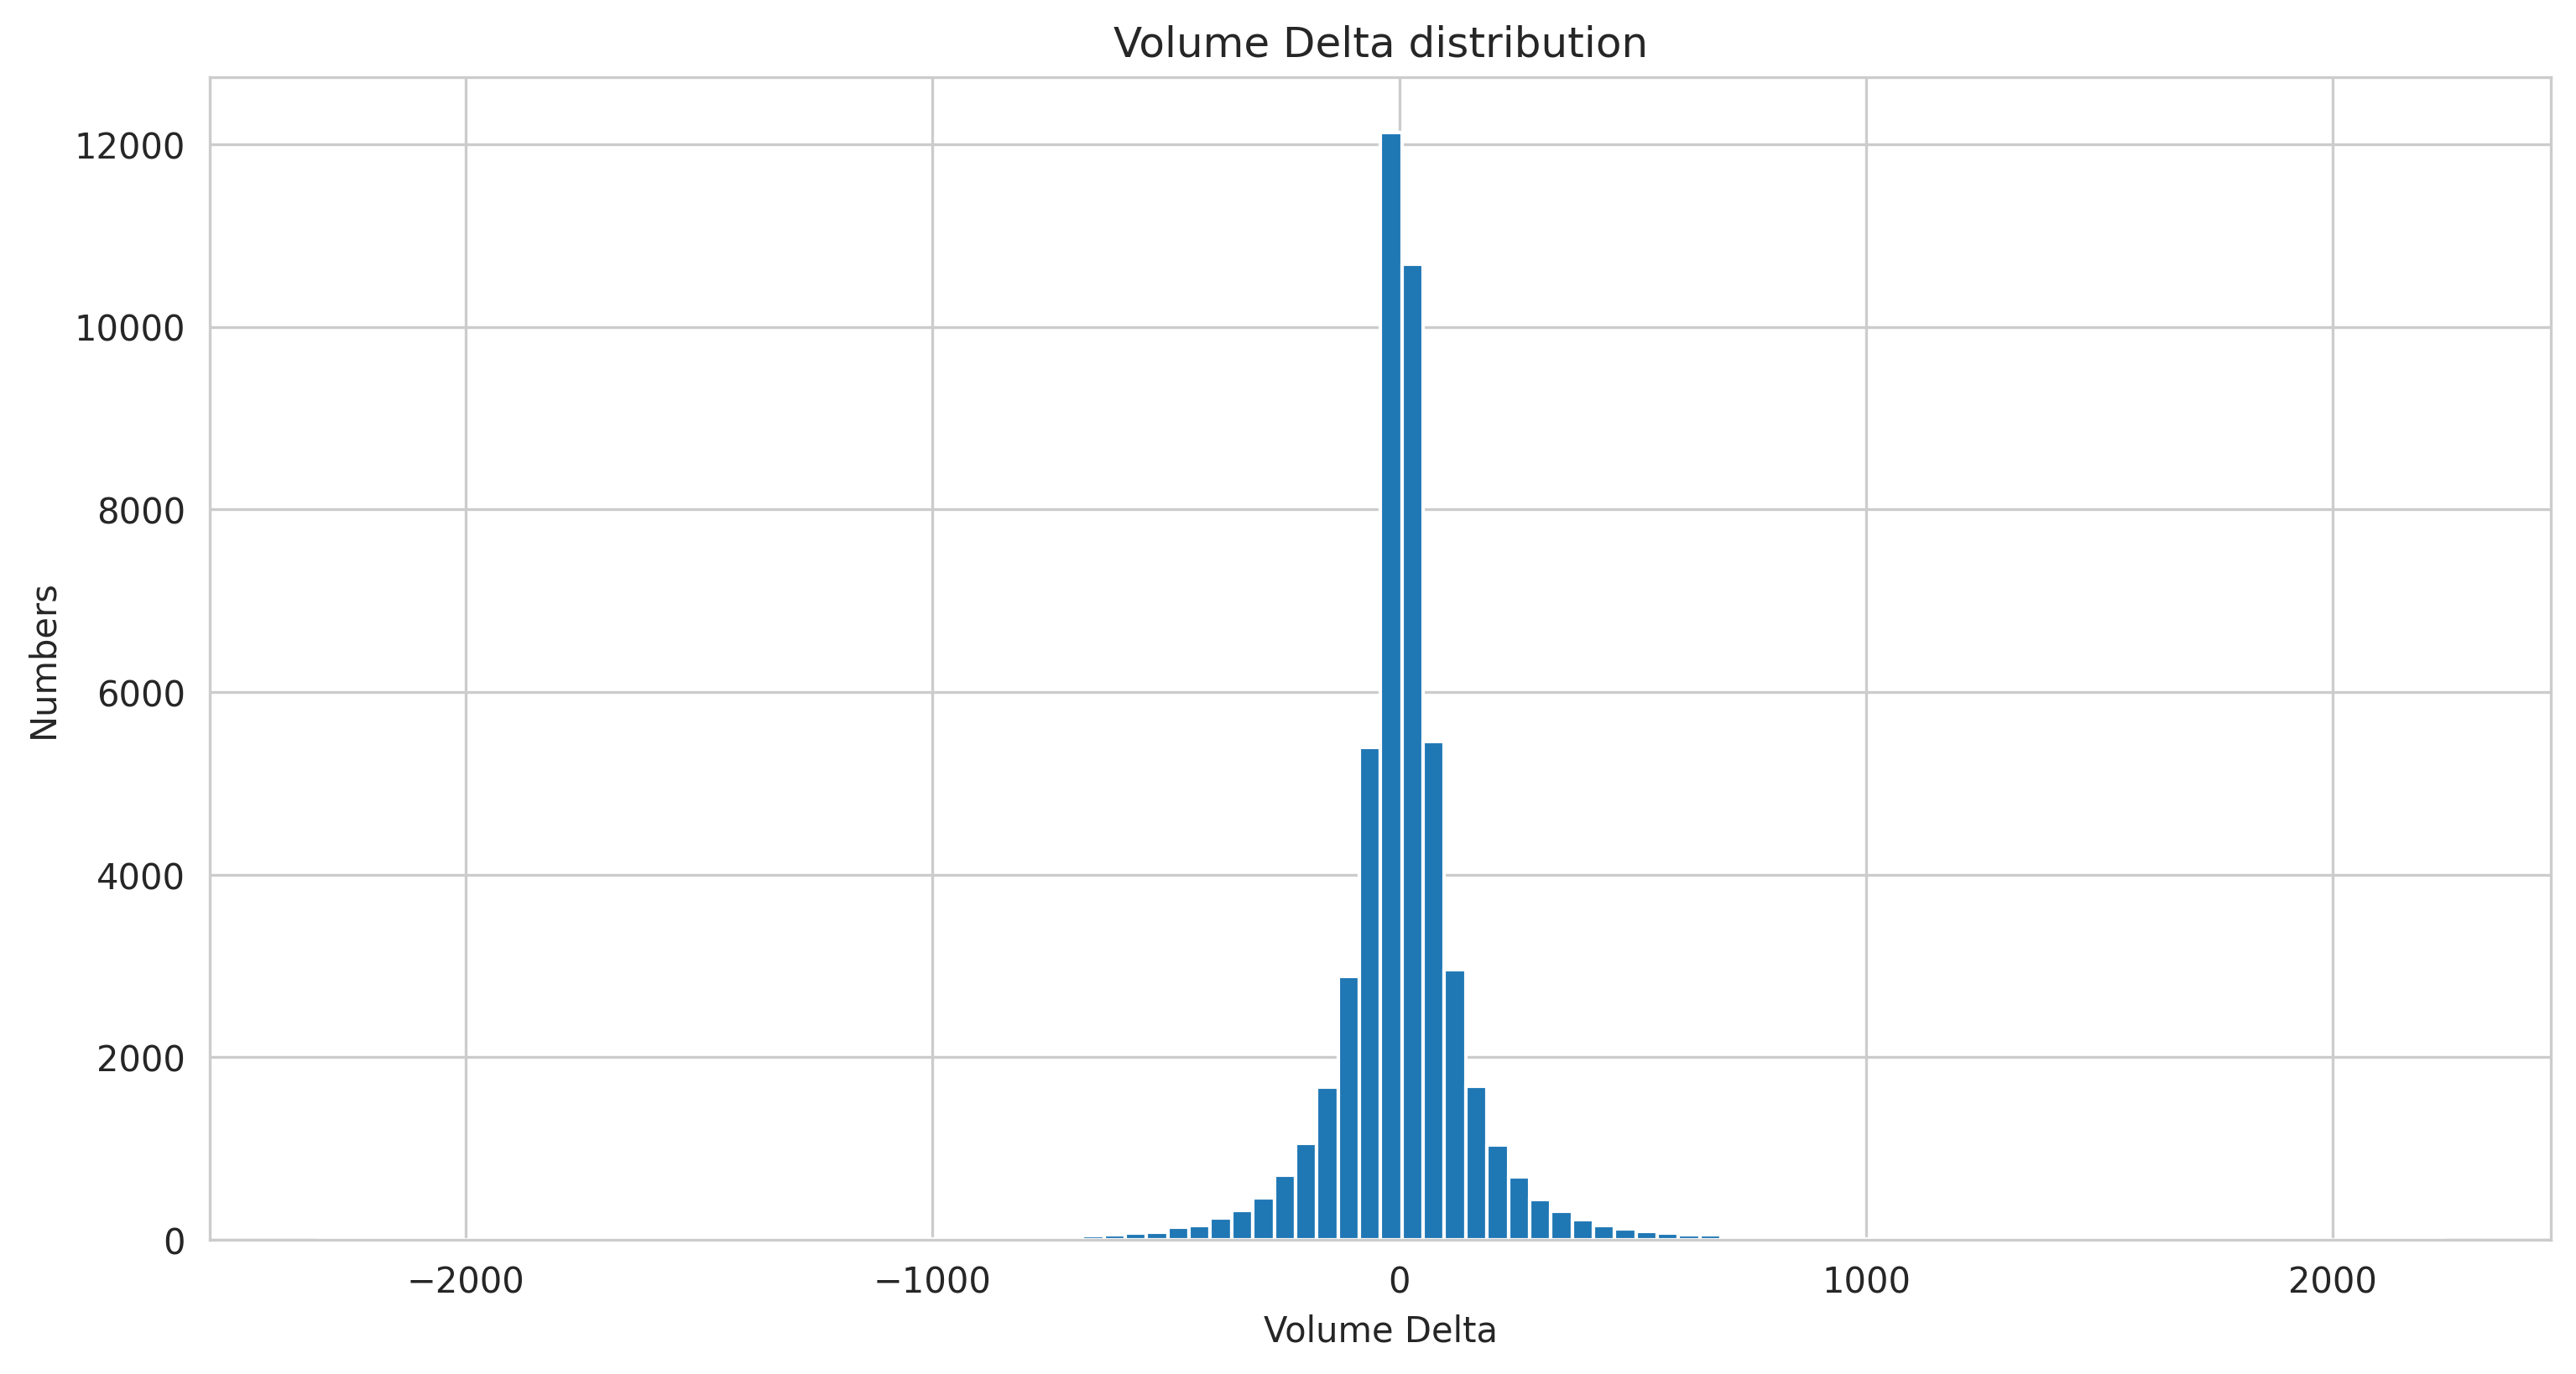

In [21]:
plt.figure(num=1,figsize=(12,6), dpi=300)
plt.hist(data['Volume_Delta'],bins=100)
plt.title('Volume Delta distribution')
plt.ylabel('Numbers')
plt.xlabel('Volume Delta')
plt.show();

### Indicate starts of days and weeks

In [22]:
data['Local_time_T_shipt_1_Down'] = data['EET_time_T'].shift(1)

In [23]:
data["Local_time_T_Delta"] = data["EET_time_T"] - data["Local_time_T_shipt_1_Down"]

In [24]:
data.head(-5)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,EET_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,-11.93,11.93,0.00029,0.00164,0.00136,0.00053,2024-05-09 00:00:00+00:00,NaT,NaT
1,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,-20.32,20.32,0.00052,0.00043,0.00029,0.00026,2024-05-09 00:15:00+00:00,2024-05-09 00:00:00+00:00,0 days 00:15:00
2,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,32.68,32.68,0.00030,0.00033,0.00016,0.00033,2024-05-09 00:30:00+00:00,2024-05-09 00:15:00+00:00,0 days 00:15:00
3,0.85986,0.86008,0.85985,0.86007,506.77,0.86019,0.86033,0.86015,0.86027,431.40,-75.37,75.37,0.00033,0.00025,0.00030,0.00020,2024-05-09 00:45:00+00:00,2024-05-09 00:30:00+00:00,0 days 00:15:00
4,0.86004,0.86010,0.85990,0.86009,223.77,0.86028,0.86028,0.86011,0.86020,219.30,-4.47,4.47,0.00024,0.00018,0.00021,0.00011,2024-05-09 01:00:00+00:00,2024-05-09 00:45:00+00:00,0 days 00:15:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49798,0.86440,0.86460,0.86438,0.86458,404.70,0.86446,0.86467,0.86445,0.86465,652.54,247.84,247.84,0.00006,0.00007,0.00007,0.00007,2026-05-08 21:30:00+00:00,2026-05-08 21:15:00+00:00,0 days 00:15:00
49799,0.86460,0.86465,0.86449,0.86462,798.49,0.86464,0.86472,0.86455,0.86471,759.10,-39.39,39.39,0.00004,0.00007,0.00006,0.00009,2026-05-08 21:45:00+00:00,2026-05-08 21:30:00+00:00,0 days 00:15:00
49800,0.86463,0.86467,0.86453,0.86465,454.06,0.86471,0.86472,0.86461,0.86470,407.69,-46.37,46.37,0.00008,0.00005,0.00008,0.00005,2026-05-08 22:00:00+00:00,2026-05-08 21:45:00+00:00,0 days 00:15:00
49801,0.86464,0.86467,0.86460,0.86464,265.80,0.86470,0.86473,0.86466,0.86470,282.22,16.42,16.42,0.00006,0.00006,0.00006,0.00006,2026-05-08 22:15:00+00:00,2026-05-08 22:00:00+00:00,0 days 00:15:00


In [25]:
data.loc[0, "Local_time_T_Delta"] = "2 days 01:01:00"
data.loc[0, "Local_time_T_Delta"]

Timedelta('2 days 01:01:00')

In [26]:
# find intervals which are longer than 15 minutes
# create a new DataFrame with the beginning of the new days

new_day = data[['Local_time_T_Delta']][data["Local_time_T_Delta"] > '0 days 00:05:00']
new_day['Local_time_T_Delta'].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
0 days 00:15:00,49699
2 days 00:15:00,96
1 days 23:15:00,4
2 days 01:15:00,4
0 days 14:15:00,2
1 days 00:15:00,2


In [27]:
# find intervals which are longer than 1 day
# create a new DataFrame with the beginning of the new weeks

new_week = data[['Local_time_T_Delta']][data['Local_time_T_Delta'] > '1 days 00:00:00']
new_week["Local_time_T_Delta"].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:01:00,1
2 days 00:15:00,96
1 days 23:15:00,4
2 days 01:15:00,4
1 days 00:15:00,2


In [28]:
data['New_day'] = 0
data['New_week'] = 0

In [29]:
# Fill in "1" when the new day starts

data.loc[data["Local_time_T_Delta"] > '0 days 00:05:00', 'New_day'] = 1

In [30]:
data[data["New_day"]==1]

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,EET_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,...,11.93,0.00029,0.00164,0.00136,0.00053,2024-05-09 00:00:00+00:00,NaT,2 days 01:01:00,1,0
1,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,...,20.32,0.00052,0.00043,0.00029,0.00026,2024-05-09 00:15:00+00:00,2024-05-09 00:00:00+00:00,0 days 00:15:00,1,0
2,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,...,32.68,0.00030,0.00033,0.00016,0.00033,2024-05-09 00:30:00+00:00,2024-05-09 00:15:00+00:00,0 days 00:15:00,1,0
3,0.85986,0.86008,0.85985,0.86007,506.77,0.86019,0.86033,0.86015,0.86027,431.40,...,75.37,0.00033,0.00025,0.00030,0.00020,2024-05-09 00:45:00+00:00,2024-05-09 00:30:00+00:00,0 days 00:15:00,1,0
4,0.86004,0.86010,0.85990,0.86009,223.77,0.86028,0.86028,0.86011,0.86020,219.30,...,4.47,0.00024,0.00018,0.00021,0.00011,2024-05-09 01:00:00+00:00,2024-05-09 00:45:00+00:00,0 days 00:15:00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49803,0.86454,0.86457,0.86433,0.86436,846.78,0.86460,0.86465,0.86441,0.86443,831.49,...,15.29,0.00006,0.00008,0.00008,0.00007,2026-05-08 22:45:00+00:00,2026-05-08 22:30:00+00:00,0 days 00:15:00,1,0
49804,0.86436,0.86437,0.86419,0.86436,631.34,0.86444,0.86445,0.86427,0.86444,701.81,...,70.47,0.00008,0.00008,0.00008,0.00008,2026-05-08 23:00:00+00:00,2026-05-08 22:45:00+00:00,0 days 00:15:00,1,0
49805,0.86438,0.86451,0.86427,0.86430,357.51,0.86445,0.86459,0.86437,0.86438,450.52,...,93.01,0.00007,0.00008,0.00010,0.00008,2026-05-08 23:15:00+00:00,2026-05-08 23:00:00+00:00,0 days 00:15:00,1,0
49806,0.86428,0.86467,0.86428,0.86454,808.64,0.86439,0.86476,0.86438,0.86466,765.78,...,42.86,0.00011,0.00009,0.00010,0.00012,2026-05-08 23:30:00+00:00,2026-05-08 23:15:00+00:00,0 days 00:15:00,1,0


In [31]:
# Fill in "1" when the new week starts

data.loc[data["Local_time_T_Delta"] > '1 days 00:00:00', 'New_week'] = 1

In [32]:
data[data["New_week"] == 1].head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,EET_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,...,11.93,0.00029,0.00164,0.00136,0.00053,2024-05-09 00:00:00+00:00,NaT,2 days 01:01:00,1,1
192,0.85963,0.86014,0.85949,0.86012,97.49,0.86062,0.86183,0.86061,0.86107,106.11,...,8.62,0.00099,0.00169,0.00112,0.00095,2024-05-13 00:00:00+00:00,2024-05-10 23:45:00+00:00,2 days 00:15:00,1,1
672,0.85512,0.85580,0.85508,0.85580,57.21,0.85683,0.85779,0.85660,0.85669,57.21,...,0.00,0.00171,0.00199,0.00152,0.00089,2024-05-20 00:00:00+00:00,2024-05-17 23:45:00+00:00,2 days 00:15:00,1,1
1152,0.85089,0.85130,0.85066,0.85124,141.75,0.85260,0.85263,0.85165,0.85185,148.98,...,7.23,0.00171,0.00133,0.00099,0.00061,2024-05-27 00:00:00+00:00,2024-05-24 23:45:00+00:00,2 days 00:15:00,1,1
1632,0.85083,0.85143,0.85066,0.85138,132.39,0.85230,0.85235,0.85173,0.85192,174.15,...,41.76,0.00147,0.00092,0.00107,0.00054,2024-06-03 00:00:00+00:00,2024-05-31 23:45:00+00:00,2 days 00:15:00,1,1


In [33]:
data2 = data.drop(['EET_time_T', 'Local_time_T_shipt_1_Down', 'Local_time_T_Delta'],axis = 1)

In [34]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,-11.93,11.93,0.00029,0.00164,0.00136,0.00053,1,1
1,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,-20.32,20.32,0.00052,0.00043,0.00029,0.00026,1,0
2,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,32.68,32.68,0.00030,0.00033,0.00016,0.00033,1,0


In [35]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float64
 1   High_Bid          49808 non-null  float64
 2   Low_Bid           49808 non-null  float64
 3   Close_Bid         49808 non-null  float64
 4   Volume_Bid        49808 non-null  float64
 5   Open_Ask          49808 non-null  float64
 6   High_Ask          49808 non-null  float64
 7   Low_Ask           49808 non-null  float64
 8   Close_Ask         49808 non-null  float64
 9   Volume_Ask        49808 non-null  float64
 10  Volume_Delta      49808 non-null  float64
 11  Volume_Delta_abs  49808 non-null  float64
 12  Open_Delta        49808 non-null  float64
 13  High_Delta        49808 non-null  float64
 14  Low_Delta         49808 non-null  float64
 15  Close_Delta       49808 non-null  float64
 16  New_day           49808 non-null  int64 

In [36]:
data = []

In [37]:
data2['Y_High_Bid'] = data2['High_Bid']
data2['Y_Low_Ask'] = data2['Low_Ask']

In [38]:
data2.tail(2)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
49806,0.86428,0.86467,0.86428,0.86454,808.64,0.86439,0.86476,0.86438,0.86466,765.78,-42.86,42.86,0.00011,0.00009,0.00010,0.00012,1,0,0.86467,0.86438
49807,0.86454,0.86463,0.86430,0.86430,964.25,0.86467,0.86488,0.86443,0.86488,1001.01,36.76,36.76,0.00013,0.00025,0.00013,0.00058,1,0,0.86463,0.86443


In [39]:
data2.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
count,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.0,49808.000000,49808.000000,49808.000000
mean,0.853783,0.853967,0.853604,0.853785,1120.336142,0.853894,0.854074,0.853712,0.853891,1125.074126,4.737984,93.569698,0.000111,0.000107,0.000108,0.000106,1.0,0.002148,0.853967,0.853712
std,0.015914,0.015912,0.015917,0.015914,974.492666,0.015909,0.015908,0.015912,0.015910,979.642321,155.797097,124.658414,0.000176,0.000159,0.000163,0.000134,0.0,0.046300,0.015912,0.015912
min,0.822380,0.822820,0.821980,0.822370,0.000000,0.822470,0.822910,0.822270,0.822460,0.000000,-2319.770000,0.000000,0.000030,0.000010,0.000040,0.000030,1.0,0.000000,0.822820,0.822270
25%,0.840400,0.840570,0.840240,0.840400,495.982500,0.840518,0.840670,0.840330,0.840510,500.100000,-46.762500,20.050000,0.000060,0.000060,0.000060,0.000060,1.0,0.000000,0.840570,0.840330
50%,0.853710,0.853900,0.853510,0.853715,901.285000,0.853850,0.854030,0.853640,0.853855,903.515000,3.335000,52.435000,0.000080,0.000070,0.000070,0.000080,1.0,0.000000,0.853900,0.853640
75%,0.867820,0.868010,0.867660,0.867820,1450.170000,0.867920,0.868110,0.867760,0.867920,1457.182500,58.142500,117.260000,0.000090,0.000090,0.000090,0.000090,1.0,0.000000,0.868010,0.867760
max,0.886380,0.886510,0.885810,0.886410,15866.280000,0.886420,0.886600,0.885880,0.886450,16541.130000,2239.220000,2319.770000,0.003420,0.003120,0.003040,0.002930,1.0,1.000000,0.886510,0.885880


### Normalisation Setup

Normalise following values: Volume_Bid, Volume_Ask, Volume_Delta, Volume_Delta_abs

In [40]:
max_volume = max(max(data2['Volume_Bid']), max(data2['Volume_Ask']))
max_volume

16541.13

In [41]:
max_volume_Delta = data2['Volume_Delta'].max()
max_volume_Delta

2239.2199999999993

In [42]:
min_volume_Delta = data2['Volume_Delta'].min()
min_volume_Delta

-2319.77

In [43]:
max_volume_Delta_abs = data2['Volume_Delta_abs'].max()
max_volume_Delta_abs

2319.77

### Normalisation

In [44]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,0.85990,0.85991,0.85875,0.85989,410.97,0.86019,0.86155,0.86011,0.86042,399.04,-11.93,11.93,0.00029,0.00164,0.00136,0.00053,1,1,0.85991,0.86011
1,0.85989,0.86002,0.85983,0.85986,454.65,0.86041,0.86045,0.86012,0.86012,434.33,-20.32,20.32,0.00052,0.00043,0.00029,0.00026,1,0,0.86002,0.86012
2,0.85983,0.85990,0.85979,0.85985,592.35,0.86013,0.86023,0.85995,0.86018,625.03,32.68,32.68,0.00030,0.00033,0.00016,0.00033,1,0,0.85990,0.85995


In [45]:
data2['Volume_Ask']  = data2['Volume_Ask'] / max_volume
data2['Volume_Bid']  = data2['Volume_Bid'] / max_volume

In [46]:
data2['Volume_Delta'] = ( data2['Volume_Delta'] - min_volume_Delta ) / (max_volume_Delta-min_volume_Delta)

In [47]:
data2['Volume_Delta_abs']  = data2['Volume_Delta_abs'] / max_volume_Delta_abs

In [48]:
delta_cols = ["Open_Delta", "High_Delta", "Low_Delta", "Close_Delta"]

scaler = MinMaxScaler(feature_range=(0, 1))

data2[delta_cols] = scaler.fit_transform(data2[delta_cols])

In [49]:
data2.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
count,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.000000,49808.0,49808.000000,49808.000000,49808.000000
mean,0.853783,0.853967,0.853604,0.853785,0.067730,0.853894,0.854074,0.853712,0.853891,0.068017,0.509873,0.040336,0.023953,0.031090,0.022501,0.026203,1.0,0.002148,0.853967,0.853712
std,0.015914,0.015912,0.015917,0.015914,0.058913,0.015909,0.015908,0.015912,0.015910,0.059225,0.034174,0.053737,0.051881,0.051272,0.054424,0.046289,0.0,0.046300,0.015912,0.015912
min,0.822380,0.822820,0.821980,0.822370,0.000000,0.822470,0.822910,0.822270,0.822460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.822820,0.822270
25%,0.840400,0.840570,0.840240,0.840400,0.029985,0.840518,0.840670,0.840330,0.840510,0.030234,0.498577,0.008643,0.008850,0.016077,0.006667,0.010345,1.0,0.000000,0.840570,0.840330
50%,0.853710,0.853900,0.853510,0.853715,0.054488,0.853850,0.854030,0.853640,0.853855,0.054622,0.509566,0.022604,0.014749,0.019293,0.010000,0.017241,1.0,0.000000,0.853900,0.853640
75%,0.867820,0.868010,0.867660,0.867820,0.087671,0.867920,0.868110,0.867760,0.867920,0.088094,0.521588,0.050548,0.017699,0.025723,0.016667,0.020690,1.0,0.000000,0.868010,0.867760
max,0.886380,0.886510,0.885810,0.886410,0.959202,0.886420,0.886600,0.885880,0.886450,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,0.886510,0.885880


In [50]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float64
 1   High_Bid          49808 non-null  float64
 2   Low_Bid           49808 non-null  float64
 3   Close_Bid         49808 non-null  float64
 4   Volume_Bid        49808 non-null  float64
 5   Open_Ask          49808 non-null  float64
 6   High_Ask          49808 non-null  float64
 7   Low_Ask           49808 non-null  float64
 8   Close_Ask         49808 non-null  float64
 9   Volume_Ask        49808 non-null  float64
 10  Volume_Delta      49808 non-null  float64
 11  Volume_Delta_abs  49808 non-null  float64
 12  Open_Delta        49808 non-null  float64
 13  High_Delta        49808 non-null  float64
 14  Low_Delta         49808 non-null  float64
 15  Close_Delta       49808 non-null  float64
 16  New_day           49808 non-null  int64 

### Preprocessing

In [51]:
# Reducing memory size

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_day', 'New_week']



In [52]:
for column in columns_float:
  data2[column] = pd.to_numeric(data2[column], downcast= 'float')

for column in columns_integer:
  data2[column] = pd.to_numeric(data2[column], downcast= 'integer')

data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float32
 1   High_Bid          49808 non-null  float32
 2   Low_Bid           49808 non-null  float32
 3   Close_Bid         49808 non-null  float32
 4   Volume_Bid        49808 non-null  float32
 5   Open_Ask          49808 non-null  float32
 6   High_Ask          49808 non-null  float32
 7   Low_Ask           49808 non-null  float32
 8   Close_Ask         49808 non-null  float32
 9   Volume_Ask        49808 non-null  float32
 10  Volume_Delta      49808 non-null  float32
 11  Volume_Delta_abs  49808 non-null  float32
 12  Open_Delta        49808 non-null  float32
 13  High_Delta        49808 non-null  float32
 14  Low_Delta         49808 non-null  float32
 15  Close_Delta       49808 non-null  float32
 16  New_day           49808 non-null  int8  

In [53]:
data3 = data2.copy()
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float32
 1   High_Bid          49808 non-null  float32
 2   Low_Bid           49808 non-null  float32
 3   Close_Bid         49808 non-null  float32
 4   Volume_Bid        49808 non-null  float32
 5   Open_Ask          49808 non-null  float32
 6   High_Ask          49808 non-null  float32
 7   Low_Ask           49808 non-null  float32
 8   Close_Ask         49808 non-null  float32
 9   Volume_Ask        49808 non-null  float32
 10  Volume_Delta      49808 non-null  float32
 11  Volume_Delta_abs  49808 non-null  float32
 12  Open_Delta        49808 non-null  float32
 13  High_Delta        49808 non-null  float32
 14  Low_Delta         49808 non-null  float32
 15  Close_Delta       49808 non-null  float32
 16  New_day           49808 non-null  int8  

<Figure size 3600x1800 with 0 Axes>

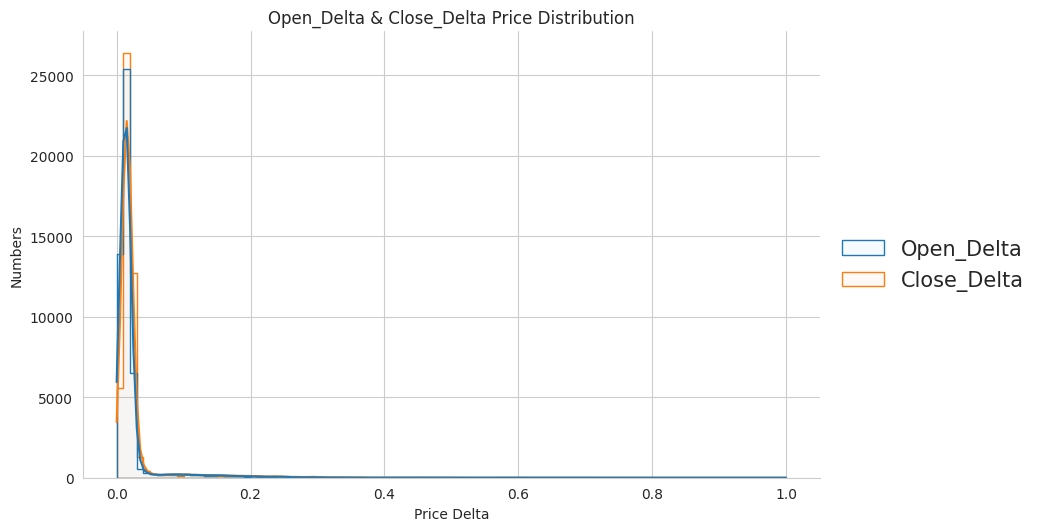

In [54]:
fig = plt.figure(figsize=(12, 6), dpi=300)
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 15.0})

sns.displot(
            data2[['Open_Delta', 'Close_Delta']],
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,
)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta')
plt.ylabel('Numbers')
plt.show();

### Data transformation for Up/Down prediction

In [55]:
data2.shape

(49808, 20)

In [56]:
n=data2.shape[0]
print(n)
p=data2.shape[1]
print(p)

49808
20


In [57]:
# 6 hour time window = 24 rows of 15 minute time-frame each
# because the time frame is not 5 minutes like in the examples a longer time frame is selected
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=24)

data2['Y_High_Bid_6h'] = data2['Y_High_Bid'].rolling(window=indexer).max()
data2['Y_Low_Ask_6h'] = data2['Y_Low_Ask'].rolling(window=indexer).min()

In [58]:
data2 [['Y_High_Bid_6h','Y_Low_Ask_6h']].tail(26)

,Y_High_Bid_6h,Y_Low_Ask_6h
49782,0.86476,0.8639
49783,0.86467,0.8639
49784,0.86467,0.8639
49785,NaN,NaN
49786,NaN,NaN
49787,NaN,NaN
49788,NaN,NaN
49789,NaN,NaN
49790,NaN,NaN
49791,NaN,NaN


In [59]:
data2['Trend_Flat'] = 0

In [60]:
# Fill in "1s" If the movement (in any direction) within 6 hours is more than £0.001
# The threshold is really low because the euro-gpb is fairly stable over short periods of time.

data2.loc[(data2["Y_High_Bid_6h"] - data2["Close_Ask"]) >= 0.001, 'Trend_Flat'] = 1
print(data2['Trend_Flat'].sum())

data2.loc[(data2["Close_Bid"] - data2["Y_Low_Ask_6h"]) >= 0.001, 'Trend_Flat'] = 1
print(data2['Trend_Flat'].sum())

12711
24257


In [61]:
print(((data2["Y_High_Bid_6h"] - data2["Close_Ask"])>= 0.001).sum())
print(((data2["Close_Bid"] - data2["Y_Low_Ask_6h"])>= 0.001).sum())

12711
13313


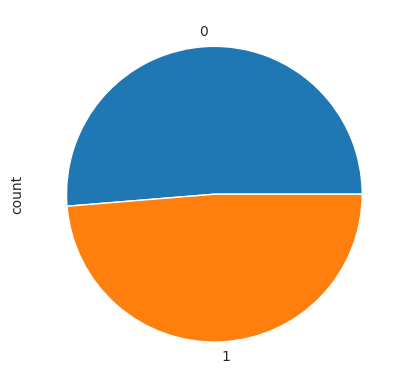

In [62]:
data2['Trend_Flat'].value_counts(sort=False).plot.pie()
plt.show()

In [63]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float32
 1   High_Bid          49808 non-null  float32
 2   Low_Bid           49808 non-null  float32
 3   Close_Bid         49808 non-null  float32
 4   Volume_Bid        49808 non-null  float32
 5   Open_Ask          49808 non-null  float32
 6   High_Ask          49808 non-null  float32
 7   Low_Ask           49808 non-null  float32
 8   Close_Ask         49808 non-null  float32
 9   Volume_Ask        49808 non-null  float32
 10  Volume_Delta      49808 non-null  float32
 11  Volume_Delta_abs  49808 non-null  float32
 12  Open_Delta        49808 non-null  float32
 13  High_Delta        49808 non-null  float32
 14  Low_Delta         49808 non-null  float32
 15  Close_Delta       49808 non-null  float32
 16  New_day           49808 non-null  int8  

In [64]:
# remove unused columns

data2 = data2.drop(['Y_High_Bid', 'Y_Low_Ask','Y_High_Bid_6h',
                    'Y_Low_Ask_6h'],axis=1)

In [65]:
# delete the last 24 rows (because we don't have prices for the last 6 hours)

for i in range(24):
        data2.drop(data2.shape[0]-1, axis=0, inplace=True)

data2.shape

(49784, 19)

In [66]:
# create outputs Dataframe

data_ay = data2[['Trend_Flat']]
data_ay.shape

(49784, 1)

In [67]:
# create inputs Dataframe

data_ax = data2.drop(['Trend_Flat'],axis=1)
data_ax.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49784 entries, 0 to 49783
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49784 non-null  float32
 1   High_Bid          49784 non-null  float32
 2   Low_Bid           49784 non-null  float32
 3   Close_Bid         49784 non-null  float32
 4   Volume_Bid        49784 non-null  float32
 5   Open_Ask          49784 non-null  float32
 6   High_Ask          49784 non-null  float32
 7   Low_Ask           49784 non-null  float32
 8   Close_Ask         49784 non-null  float32
 9   Volume_Ask        49784 non-null  float32
 10  Volume_Delta      49784 non-null  float32
 11  Volume_Delta_abs  49784 non-null  float32
 12  Open_Delta        49784 non-null  float32
 13  High_Delta        49784 non-null  float32
 14  Low_Delta         49784 non-null  float32
 15  Close_Delta       49784 non-null  float32
 16  New_day           49784 non-null  int8  

In [68]:
data_ax.shape

(49784, 18)

In [69]:
# Create inputs Numpy

data_a = np.array(data_ax)

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])
    print('\n')
    print(data_a[-2:,:])

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype)

data_a:
[[0.8599 0.8599 0.8587 0.8599 0.0248 0.8602 0.8615 0.8601 0.8604 0.0241
  0.5062 0.0051 0.0767 0.5241 0.44   0.1724 1.     1.    ]
 [0.8599 0.86   0.8598 0.8599 0.0275 0.8604 0.8605 0.8601 0.8601 0.0263
  0.5044 0.0088 0.1445 0.135  0.0833 0.0793 1.     0.    ]]


[[0.8645 0.8648 0.8644 0.8644 0.1021 0.8646 0.8648 0.8644 0.8645 0.114
  0.5519 0.0845 0.0118 0.0193 0.0067 0.0172 1.     0.    ]
 [0.8644 0.8645 0.8641 0.8641 0.0963 0.8645 0.8646 0.8641 0.8642 0.0921
  0.4937 0.0297 0.0088 0.0161 0.0067 0.0138 1.     0.    ]]
numpy size: =  (49784, 18)
type:  float32


In [70]:
# Create outputs Numpy

data_y = np.array(data_ay)

print("data_a:")
print(data_y[:3,:])
print('\n')
print(data_y[-3:,:])

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype)

data_a:
[[0]
 [0]
 [0]]


[[0]
 [0]
 [0]]
numpy size: =  (49784, 1)
type:  int64


In [71]:
len(data_a)

49784

In [72]:
n_small = 48000    # reduce the dataset size

N=232               # sliding window depth

L=n_small-N        # number of sliding window slices
t=data_a.shape[1]  # features number
print('Size of a three-dimensional inputs tensor: ',L,N,t)

Size of a three-dimensional inputs tensor:  47768 232 18


In [73]:
# create imputs zeros 3D tensors with 'float32'

data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [74]:
# create a one-dimensional zeros vector of answers

Y = np.zeros((L, 1), dtype= 'float32')  # We will predict Attention - Wait for signals

In [75]:
# fill the imputs 3D tansor (data_b)
# and the array of answers Y

print('L = n_small - N = ', n_small-N, L)
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]

    Y[k,0] = data_y[k+N-1,0]   # Trend-Flat signal

print(k)                       # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N =  47768 47768


100%|██████████| 47768/47768 [00:00<00:00, 77226.06it/s]

47767
data_b: 
 [[[0.8599     0.85991    0.85875    ... 0.1724138  1.         1.        ]
  [0.85989    0.86002    0.85983    ... 0.07931034 1.         0.        ]
  [0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  ...
  [0.85987    0.8599     0.85951    ... 0.01034483 1.         0.        ]
  [0.85961    0.85996    0.85956    ... 0.01724138 1.         0.        ]
  [0.85978    0.85993    0.85973    ... 0.01034483 1.         0.        ]]

 [[0.85989    0.86002    0.85983    ... 0.07931034 1.         0.        ]
  [0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  [0.85986    0.86008    0.85985    ... 0.05862069 1.         0.        ]
  ...
  [0.85961    0.85996    0.85956    ... 0.01724138 1.         0.        ]
  [0.85978    0.85993    0.85973    ... 0.01034483 1.         0.        ]
  [0.85985    0.86036    0.85977    ... 0.01724138 1.         0.        ]]

 [[0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  [0.8

In [76]:
# Clean memory

data_ax = []
data_ay = []
data_a = []
data_y = []

# Predicting if Stock goes up or down

### Train Test Split
- 90% for training and validation
- 10% for testing

In [77]:
# Separate "data_b" and "Y" into X_train, X_test, y_train, y_test i.e. getting training and testing set for the model.

X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1, shuffle = False, stratify = None, random_state=871)

In [78]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(42991, 232, 18)
(42991, 1)
(4777, 232, 18)
(4777, 1)


### Balancing Classes in the Dataset

In [ ]:
y_train.ndim   #  y_train dimensi

2

In [ ]:
# compute_class_weight only operates on one-dimensional arrays of output data.
# Convert y_train_1 and y_test_1 to one-dimensional arrays

y_train_1 = y_train.ravel()
y_test_1  = y_test.ravel()

print(y_train_1.shape)
print(y_test_1.shape)

(42991,)
(4777,)


In [ ]:
class_weights=compute_class_weight('balanced',classes=np.unique(y_train_1),y=y_train_1)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

In [ ]:
class_weight_dict

{0: np.float64(1.005496304612218), 1: np.float64(0.99456345717855)}

In [ ]:
EPOCHS = 100
BATCH_SIZE = 32

In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

## Base model

### Training

In [ ]:
mc = ModelCheckpoint('model_1.keras',monitor='val_loss',
                     mode='min', verbose=1, save_best_only=True)

In [ ]:
model_1 = keras.Sequential([
    keras.layers.LSTM(50, activation='relu', input_shape=(232, 18)),
    keras.layers.Dense(1, activation='sigmoid')
])

print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model_1.compile(optimizer="adamW", loss="binary_crossentropy",
              metrics=['accuracy'])

In [ ]:
history_1 = model_1.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_split=0.2, shuffle=True,
                    verbose=1, callbacks=[es, mc],
                    class_weight=class_weight_dict)

Epoch 1/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5381 - loss: 25396.6502
Epoch 1: val_loss improved from None to 0.73124, saving model to model_1.keras

Epoch 1: finished saving model to model_1.keras
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.5249 - loss: 15168.3975 - val_accuracy: 0.4890 - val_loss: 0.7312
Epoch 2/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5502 - loss: 0.6787
Epoch 2: val_loss improved from 0.73124 to 0.69895, saving model to model_1.keras

Epoch 2: finished saving model to model_1.keras
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.5460 - loss: 0.6757 - val_accuracy: 0.5123 - val_loss: 0.6990
Epoch 3/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5382 - loss: 0.6720
Epoch 3: val_loss did not improve from 0.69895
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.5365 - loss: 0.6724 - val_accuracy: 0.5227 - val_loss: 0.7723
Epoch 4/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/st

In [ ]:
model_1=keras.models.load_model('model_1.keras')

### Evaluating

In [ ]:
scores = model_1.evaluate(X_test, y_test, verbose=1)
scores

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6741 - loss: 0.6187


[0.6186898350715637, 0.6740632057189941]

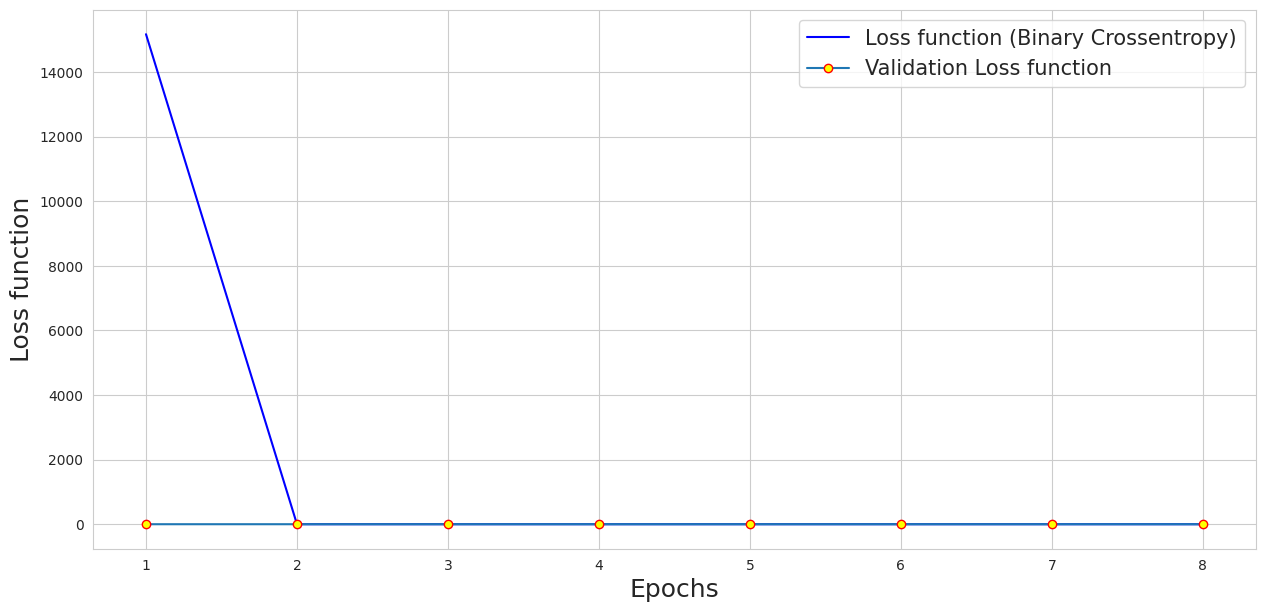

In [ ]:
# Detailed Loss function graph

history_dict = history_1.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, marker='o', markeredgecolor='red',
         markerfacecolor='yellow', label='Validation Loss function')
plt.xlabel('Epochs', size=18)
plt.ylabel('Loss function', size=18)
plt.legend()
plt.show()

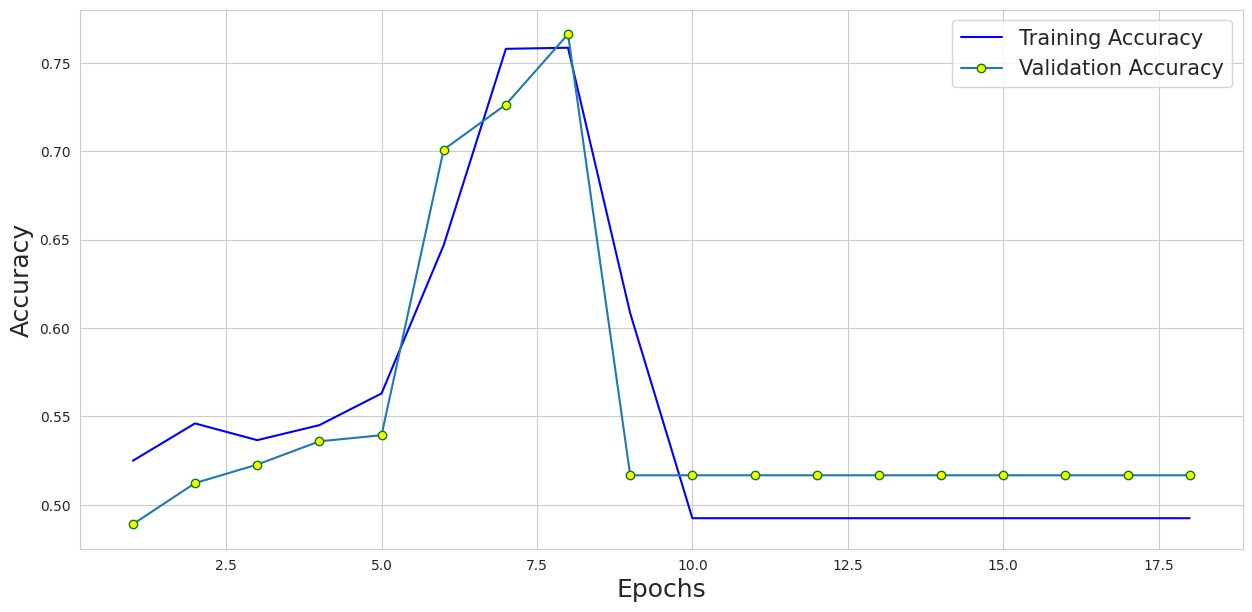

In [ ]:
# Detailed Accuracy
history_dict = history_1.history

Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]

epochs = range(1, len(Accuracy_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, marker='o', markeredgecolor='green',
         markerfacecolor='yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size=18)
plt.ylabel('Accuracy', size=18)
plt.legend()
plt.show()

In [ ]:
# Calculate the prediction vector
pred = model_1(X_test)
print(pred)

tf.Tensor(
[[0.76962674]
 [0.76380384]
 [0.7658055 ]
 ...
 [0.23554364]
 [0.2636728 ]
 [0.29358426]], shape=(4777, 1), dtype=float32)


In [ ]:
pred = model_1.predict(X_test)

# Check: we take a random element random.randint() and look:
# what is the difference between test and predict

n_rec = random.randint(0, X_test.shape[0])
print(n_rec)

print("Predicted probability:", pred[n_rec], ", right answer:", y_test[n_rec])
print(pred)

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
3751
Predicted probability: [0.78537744] , right answer: [1.]
[[0.76962715]
 [0.76380384]
 [0.765806  ]
 ...
 [0.2355438 ]
 [0.26367223]
 [0.29358393]]


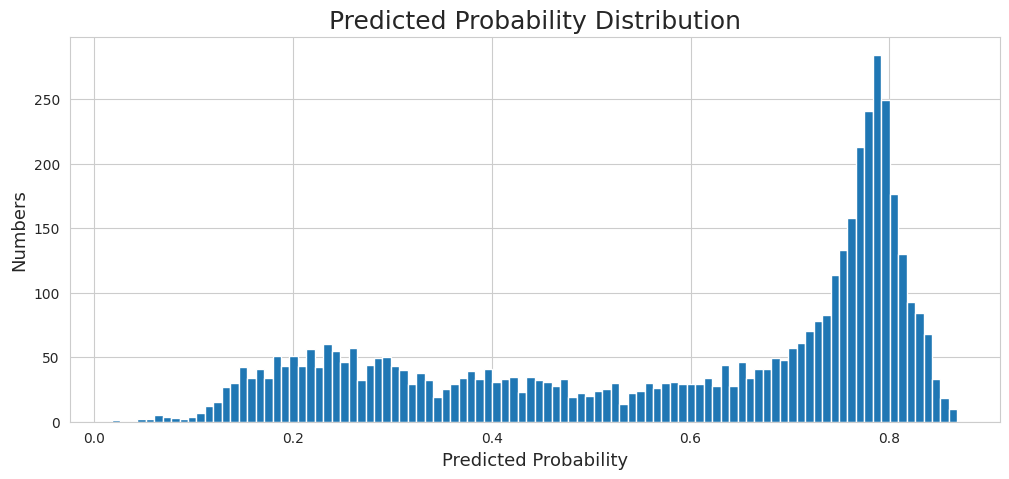

In [ ]:
plt.figure(num=1,figsize=(12,5))
plt.hist(pred,bins=100)
plt.title('Predicted Probability Distribution',size=18)
plt.ylabel('Numbers',size=13)
plt.xlabel('Predicted Probability',size=13)
plt.show();

In [ ]:
pred_binary = np.round(pred)

In [ ]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.81      0.52      0.64      2589
         1.0       0.60      0.85      0.71      2188

    accuracy                           0.67      4777
   macro avg       0.70      0.69      0.67      4777
weighted avg       0.71      0.67      0.67      4777



In [ ]:
# Let's change the ratio: Only values greater than or equal
# to 60% (0.60) will become "1" ("Attention" signal)

pred_binary = (pred >= 0.60).astype(int)

In [ ]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.78      0.60      0.67      2589
         1.0       0.62      0.80      0.70      2188

    accuracy                           0.69      4777
   macro avg       0.70      0.70      0.69      4777
weighted avg       0.71      0.69      0.69      4777



In [ ]:
ErrorMetrics = []

In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_test, pred_binary),
    "Precision": precision_score(y_test, pred_binary, average="macro"),
    "Recall": recall_score(y_test, pred_binary, average="macro"),
    "F1_Score": f1_score(y_test, pred_binary, average="macro")
}

ErrorMetrics.append(metrics)

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)

print(ErrorMetrics_pd)

   Accuracy  Precision    Recall  F1_Score
0   0.68767   0.700482  0.696143  0.687105


## Model 2 Hyperparameter optimisation

### Training

In [ ]:
timesteps = 232
features  = 18

In [ ]:
mc = ModelCheckpoint('model_2.keras', monitor='val_loss',
                     mode='min', verbose=1, save_best_only=True)

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=20, max_value=100, step=20),
              return_sequences=True, input_shape=(timesteps, features)))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=10, max_value=50, step=10)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=AdamW(learning_rate=hp.Choice('learning_rate',
                                                values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=3,
    directory='my_dir',
    project_name='lstm_tuning'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [106]:
tuner.search(X_train, y_train, epochs=15,
             validation_split=0.2, shuffle=True,
             verbose=1,
             class_weight=class_weight_dict)

Trial 10 Complete [00h 16m 57s]
val_accuracy: 0.7619490424791971

Best val_accuracy So Far: 0.7715238134066263
Total elapsed time: 02h 56m 34s


In [107]:
model_2 = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [108]:
print(model_2.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 232, 40)        │         9,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 232, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        18,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,691 (108.17 KB)

 Trainable params: 27,691 (108.17 KB)

 Non-trainable params: 0 (0.00 B)

None


In [109]:
history_2 = model_2.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_split=0.2, shuffle=True,
                    verbose=1, callbacks=[es, mc],
                    class_weight=class_weight_dict)

Epoch 1/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7587 - loss: 0.5166
Epoch 1: val_loss improved from None to 0.51683, saving model to model_2.keras

Epoch 1: finished saving model to model_2.keras
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.7617 - loss: 0.5154 - val_accuracy: 0.7635 - val_loss: 0.5168
Epoch 2/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7622 - loss: 0.5124
Epoch 2: val_loss improved from 0.51683 to 0.51570, saving model to model_2.keras

Epoch 2: finished saving model to model_2.keras
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.7653 - loss: 0.5100 - val_accuracy: 0.7611 - val_loss: 0.5157
Epoch 3/100
1073/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7679 - loss: 0.5057
Epoch 3: val_loss did not improve from 0.51570
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.7679 - loss: 0.5053 - val_accuracy: 0.7603 - val_loss: 0.5251
Epoch 4/100
1073/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc

In [110]:
model_2=keras.models.load_model('model_2.keras')

### Evaluating

In [111]:
scores = model_2.evaluate(X_test, y_test, verbose=1)
scores

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7174 - loss: 0.5668


[0.5667835474014282, 0.7173958420753479]

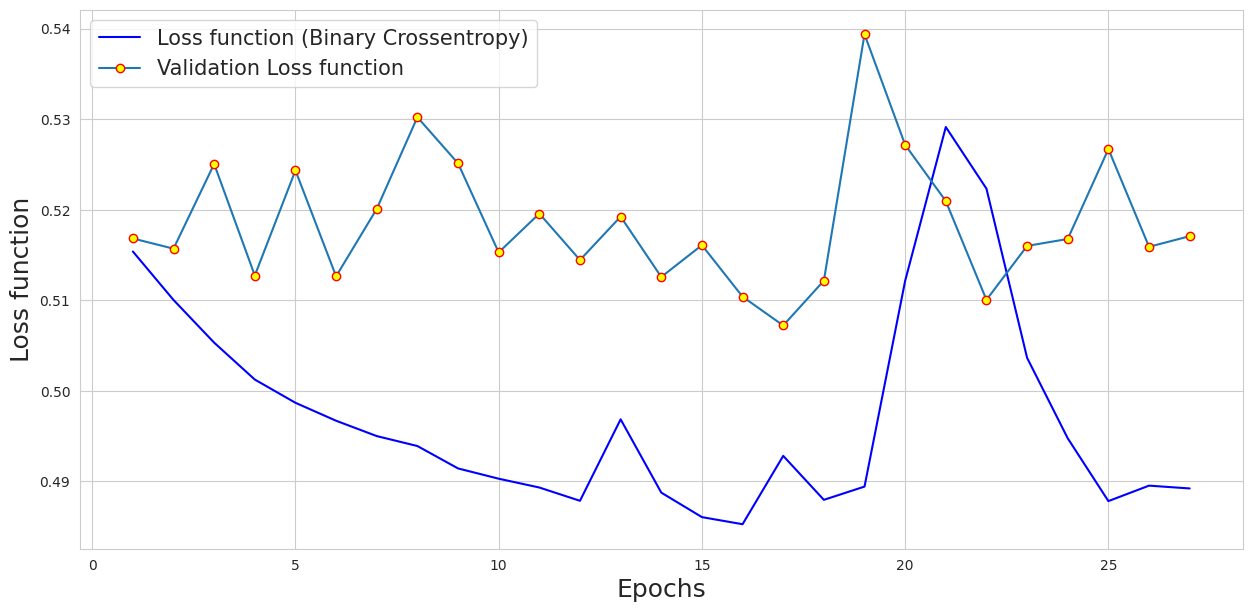

In [112]:
# Detailed Loss function graph
history_dict = history_2.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, marker='o', markeredgecolor='red',
         markerfacecolor='yellow', label='Validation Loss function')
plt.xlabel('Epochs', size=18)
plt.ylabel('Loss function', size=18)
plt.legend()
plt.show()

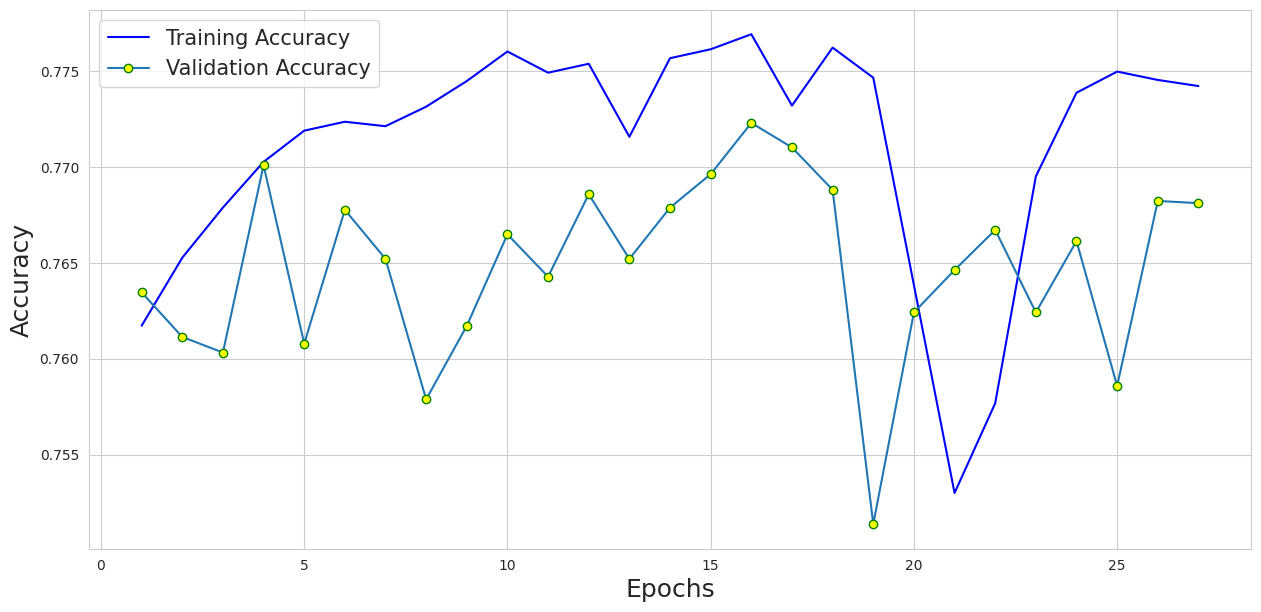

In [113]:
# Detailed Accuracy
history_dict = history_2.history

Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]

epochs = range(1, len(Accuracy_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, marker='o', markeredgecolor='green',
         markerfacecolor='yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size=18)
plt.ylabel('Accuracy', size=18)
plt.legend()
plt.show()

In [114]:
# Calculate the prediction vector
# pred = model_2(X_test)

pred = model_2.predict(X_test)
pred_binary = np.round(pred)

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [115]:
error_metrics_report_2 = classification_report(y_test, pred_binary)
print(error_metrics_report_2)

              precision    recall  f1-score   support

         0.0       0.79      0.66      0.72      2589
         1.0       0.66      0.79      0.72      2188

    accuracy                           0.72      4777
   macro avg       0.72      0.72      0.72      4777
weighted avg       0.73      0.72      0.72      4777



In [116]:
metrics = {
    "Accuracy": accuracy_score(y_test, pred_binary),
    "Precision": precision_score(y_test, pred_binary, average="macro"),
    "Recall": recall_score(y_test, pred_binary, average="macro"),
    "F1_Score": f1_score(y_test, pred_binary, average="macro")
}

ErrorMetrics.append(metrics)

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)

print(ErrorMetrics_pd)

   Accuracy  Precision    Recall  F1_Score
0  0.687670   0.700482  0.696143  0.687105
1  0.717396   0.723349  0.722929  0.717388


## Model 3 Transformer

this model is based of "Timeseries classification with a Transformer model by Theodoros Ntakouris" (https://keras.io/examples/timeseries/timeseries_classification_transformer/)

### Training

In [117]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [118]:
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,):

    inputs = keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)

In [119]:
input_shape = X_train.shape[1:]

model = build_model(
    input_shape,
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
)


model.compile(optimizer="adamW", loss="binary_crossentropy",
              metrics=['accuracy'])

mc = ModelCheckpoint('model_transformer.keras', monitor='val_loss',
                     mode='min', verbose=1, save_best_only=True)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 232, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 232, 18)   │     76,818 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 232, 18)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 232, 18)   │         36 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 232, 4)    │         76 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 232, 4)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 232, 18)   │         90 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 232, 18)   │     76,818 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 232, 18)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 232, 4)    │         76 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 232, 4)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 232, 18)   │         90 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 310,785 (1.19 MB)

 Trainable params: 310,785 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
history_3 = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_split=0.2, shuffle=True,
                    verbose=1, callbacks=[es, mc],
                    class_weight=class_weight_dict)

Epoch 1/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5049 - loss: 0.7237
Epoch 1: val_loss improved from None to 0.69336, saving model to model_transformer.keras

Epoch 1: finished saving model to model_transformer.keras
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 109s 79ms/step - accuracy: 0.5010 - loss: 0.7026 - val_accuracy: 0.4833 - val_loss: 0.6934
Epoch 2/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5010 - loss: 0.6935
Epoch 2: val_loss did not improve from 0.69336
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 69s 64ms/step - accuracy: 0.5120 - loss: 0.6913 - val_accuracy: 0.5189 - val_loss: 0.6986
Epoch 3/100
1074/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5259 - loss: 0.6850
Epoch 3: val_loss did not improve from 0.69336
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 69s 64ms/step - accuracy: 0.5261 - loss: 0.6846 - val_accuracy: 0.5181 - val_loss: 0.7110
Epoch 4/100
1074/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5324 - loss: 0.6806
Epoch 4: val_loss did not improve 

In [121]:
model_transformer=keras.models.load_model('model_transformer.keras')

### Evaluating

In [122]:
scores = model_transformer.evaluate(X_test, y_test, verbose=1)
scores

150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4580 - loss: 0.6938


[0.6938139200210571, 0.45802804827690125]

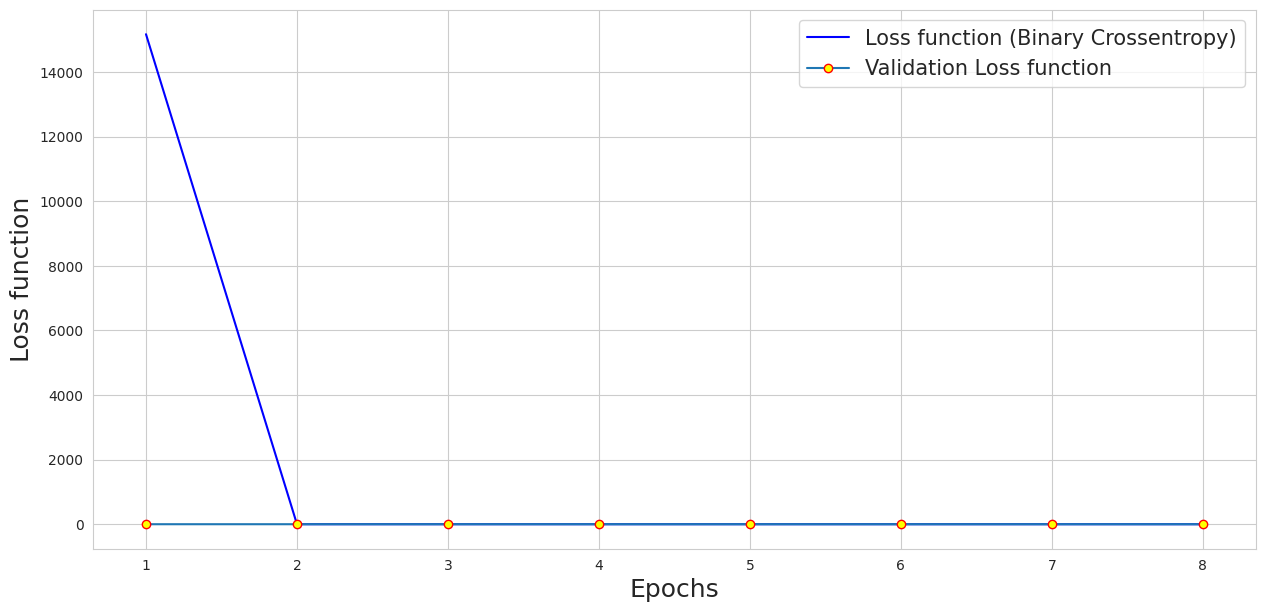

In [123]:
# Detailed Loss function graph
history_dict = history_1.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, marker='o', markeredgecolor='red',
         markerfacecolor='yellow', label='Validation Loss function')
plt.xlabel('Epochs', size=18)
plt.ylabel('Loss function', size=18)
plt.legend()
plt.show()

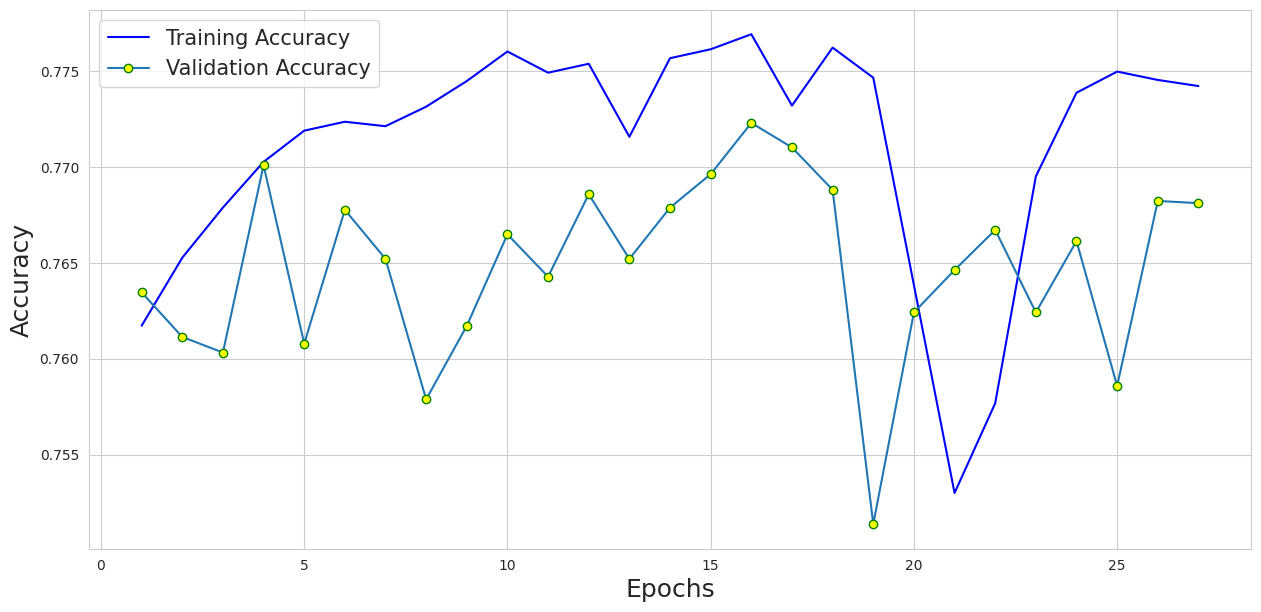

In [124]:
# Detailed Accuracy
history_dict = history_2.history

Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]

epochs = range(1, len(Accuracy_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, marker='o', markeredgecolor='green',
         markerfacecolor='yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size=18)
plt.ylabel('Accuracy', size=18)
plt.legend()
plt.show()

In [125]:
# Calculate the prediction vector
pred = model_transformer.predict(X_test)
pred_binary = np.round(pred)

150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step


In [126]:
error_metrics_report_2 = classification_report(y_test, pred_binary)
print(error_metrics_report_2)

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      2589
         1.0       0.46      1.00      0.63      2188

    accuracy                           0.46      4777
   macro avg       0.23      0.50      0.31      4777
weighted avg       0.21      0.46      0.29      4777



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [127]:
metrics = {
    "Accuracy": accuracy_score(y_test, pred_binary),
    "Precision": precision_score(y_test, pred_binary, average="macro"),
    "Recall": recall_score(y_test, pred_binary, average="macro"),
    "F1_Score": f1_score(y_test, pred_binary, average="macro")
}

ErrorMetrics.append(metrics)

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)

print(ErrorMetrics_pd)

   Accuracy  Precision    Recall  F1_Score
0  0.687670   0.700482  0.696143  0.687105
1  0.717396   0.723349  0.722929  0.717388
2  0.458028   0.229014  0.500000  0.314142


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## UP/DOWN Model Comparision

In [128]:
ErrorMetrics_pd.index = ["Base Simple Model", "Hyperparameter optimisation", "Transformer"]
ErrorMetrics_pd

,Accuracy,Precision,Recall,F1_Score
Base Simple Model,0.687670,0.700482,0.696143,0.687105
Hyperparameter optimisation,0.717396,0.723349,0.722929,0.717388
Transformer,0.458028,0.229014,0.500000,0.314142


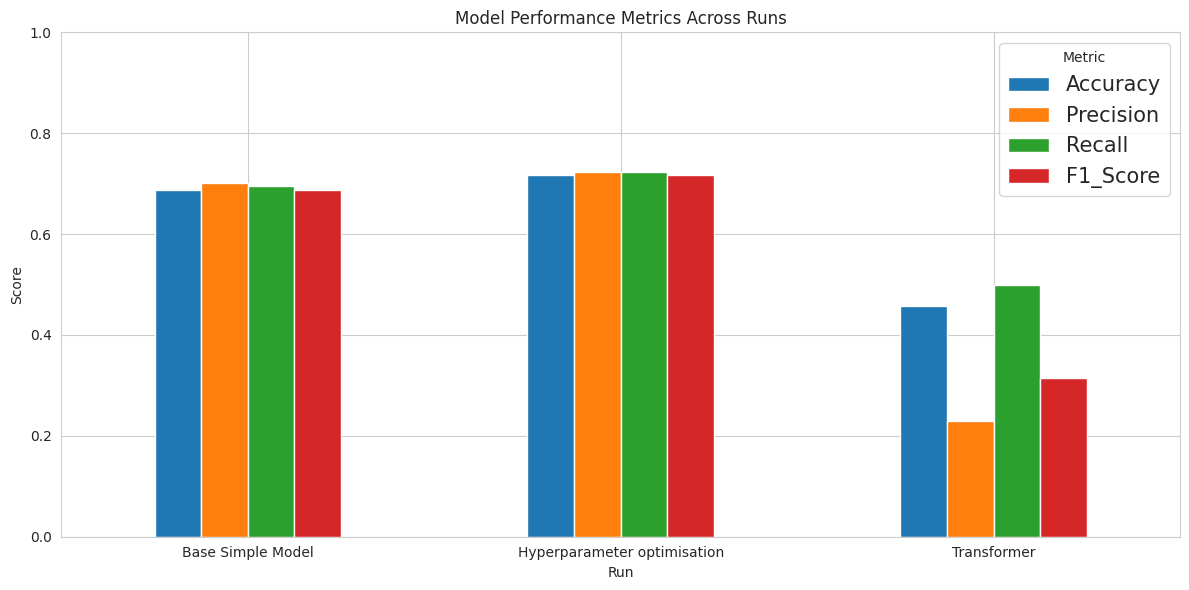

In [129]:
ErrorMetrics_pd.plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Metrics Across Runs")
plt.xlabel("Run")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Price Prediction during timeframes

## Processing

In [79]:
n = data3.shape[0]
print(n)
p = data3.shape[1]
print(p)

49808
20


In [80]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float32
 1   High_Bid          49808 non-null  float32
 2   Low_Bid           49808 non-null  float32
 3   Close_Bid         49808 non-null  float32
 4   Volume_Bid        49808 non-null  float32
 5   Open_Ask          49808 non-null  float32
 6   High_Ask          49808 non-null  float32
 7   Low_Ask           49808 non-null  float32
 8   Close_Ask         49808 non-null  float32
 9   Volume_Ask        49808 non-null  float32
 10  Volume_Delta      49808 non-null  float32
 11  Volume_Delta_abs  49808 non-null  float32
 12  Open_Delta        49808 non-null  float32
 13  High_Delta        49808 non-null  float32
 14  Low_Delta         49808 non-null  float32
 15  Close_Delta       49808 non-null  float32
 16  New_day           49808 non-null  int8  

In [81]:
data_ax = []
data_ay = []
data_a = []
data_y = []

In [82]:
data_ax = data3.drop(['Y_High_Bid','Y_Low_Ask'], axis = 1)
data_ax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49808 entries, 0 to 49807
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          49808 non-null  float32
 1   High_Bid          49808 non-null  float32
 2   Low_Bid           49808 non-null  float32
 3   Close_Bid         49808 non-null  float32
 4   Volume_Bid        49808 non-null  float32
 5   Open_Ask          49808 non-null  float32
 6   High_Ask          49808 non-null  float32
 7   Low_Ask           49808 non-null  float32
 8   Close_Ask         49808 non-null  float32
 9   Volume_Ask        49808 non-null  float32
 10  Volume_Delta      49808 non-null  float32
 11  Volume_Delta_abs  49808 non-null  float32
 12  Open_Delta        49808 non-null  float32
 13  High_Delta        49808 non-null  float32
 14  Low_Delta         49808 non-null  float32
 15  Close_Delta       49808 non-null  float32
 16  New_day           49808 non-null  int8  

In [83]:
data_ax.shape

(49808, 18)

In [84]:
data_ay = data3[['Y_High_Bid','Y_Low_Ask']]
print(data_ay.shape)
print(data_ay.head(6))
print(data_ay.tail(10))

(49808, 2)
   Y_High_Bid  Y_Low_Ask
0     0.85991    0.86011
1     0.86002    0.86012
2     0.85990    0.85995
3     0.86008    0.86015
4     0.86010    0.86011
5     0.86013    0.86015
       Y_High_Bid  Y_Low_Ask
49798     0.86460    0.86445
49799     0.86465    0.86455
49800     0.86467    0.86461
49801     0.86467    0.86466
49802     0.86466    0.86458
49803     0.86457    0.86441
49804     0.86437    0.86427
49805     0.86451    0.86437
49806     0.86467    0.86438
49807     0.86463    0.86443


In [85]:
data_ay = data_ay.shift(-1)
print(data_ay.shape)
print(data_ay.head(6))
print(data_ay.tail(10))

(49808, 2)
   Y_High_Bid  Y_Low_Ask
0     0.86002    0.86012
1     0.85990    0.85995
2     0.86008    0.86015
3     0.86010    0.86011
4     0.86013    0.86015
5     0.86016    0.86017
       Y_High_Bid  Y_Low_Ask
49798     0.86465    0.86455
49799     0.86467    0.86461
49800     0.86467    0.86466
49801     0.86466    0.86458
49802     0.86457    0.86441
49803     0.86437    0.86427
49804     0.86451    0.86437
49805     0.86467    0.86438
49806     0.86463    0.86443
49807         NaN        NaN


In [86]:
# 6 hour time window = 24 rows of 15 minute time-frame each
# because the time frame is not 5 minutes like in the examples a longer time frame is selected
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=24)

data_ay['Y_High_Bid_6h'] = data_ay['Y_High_Bid'].rolling(window=indexer).max()
data_ay['Y_Low_Ask_6h']  = data_ay['Y_Low_Ask'].rolling(window=indexer).min()

In [87]:
data_ay.head(10)

,Y_High_Bid,Y_Low_Ask,Y_High_Bid_6h,Y_Low_Ask_6h
0,0.86002,0.86012,0.86029,0.85995
1,0.85990,0.85995,0.86029,0.85995
2,0.86008,0.86015,0.86029,0.85999
3,0.86010,0.86011,0.86029,0.85999
4,0.86013,0.86015,0.86029,0.85999
5,0.86016,0.86017,0.86029,0.85999
6,0.86011,0.86016,0.86029,0.85999
7,0.86011,0.86015,0.86031,0.85999
8,0.86013,0.86015,0.86031,0.85999
9,0.86020,0.86017,0.86031,0.85999


In [88]:
data_ay.tail(25)

,Y_High_Bid,Y_Low_Ask,Y_High_Bid_6h,Y_Low_Ask_6h
49783,0.86457,0.86417,0.86467,0.8639
49784,0.86426,0.86400,NaN,NaN
49785,0.86414,0.86390,NaN,NaN
49786,0.86450,0.86415,NaN,NaN
49787,0.86427,0.86404,NaN,NaN
49788,0.86429,0.86419,NaN,NaN
49789,0.86451,0.86421,NaN,NaN
49790,0.86454,0.86436,NaN,NaN
49791,0.86446,0.86439,NaN,NaN
49792,0.86451,0.86435,NaN,NaN


In [89]:
data_ay = data_ay.drop(['Y_High_Bid','Y_Low_Ask'], axis =1)

data_ay.tail(25)

,Y_High_Bid_6h,Y_Low_Ask_6h
49783,0.86467,0.8639
49784,NaN,NaN
49785,NaN,NaN
49786,NaN,NaN
49787,NaN,NaN
49788,NaN,NaN
49789,NaN,NaN
49790,NaN,NaN
49791,NaN,NaN
49792,NaN,NaN


In [90]:
for i in range(24):
    data_ax.drop(data_ax.shape[0]-1, axis=0, inplace= True)
    data_ay.drop(data_ay.shape[0]-1, axis=0, inplace= True)

data_ay.shape

(49784, 2)

In [91]:
data_ay.tail(3)

,Y_High_Bid_6h,Y_Low_Ask_6h
49781,0.86476,0.8639
49782,0.86467,0.8639
49783,0.86467,0.8639


In [92]:
data_ax.shape

(49784, 18)

In [93]:
data_ax = data_ax.to_numpy()
data_ay = data_ay.to_numpy()

print(data_ax.shape, '\n', data_ay.shape)

(49784, 18) 
 (49784, 2)


In [94]:
n= len(data_ay)
n

49784

In [95]:
N = 232
L = n-N
t = data_ax.shape[1]

print('Size of a three-dimensional inputs tensor: ', L,N,t)

Size of a three-dimensional inputs tensor:  49552 232 18


In [96]:
data_b = np.zeros((L,N,t), dtype= 'float32')

In [97]:
Y = np.zeros((L,2),dtype= 'float32')

In [98]:
# fill the inputs 3D tensor (data_b)
# and the matrix of outputs Y

print('L = n - N - 24 = ', n-N-24, L)

for k in tqdm(range(L)):
    data_b[k, :, :] = data_ax[k:k+N, :]

    Y[k,0] = data_ay[k+N-1,0]   # Y_High_Bid_6h - max 6 hours future price
    Y[k,1] = data_ay[k+N-1,1]   # Y_Low_Ask_6h -  min 6 hours future price

print(k) # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n - N - 24 =  49528 49552


100%|██████████| 49552/49552 [00:00<00:00, 75648.11it/s]

49551
data_b: 
 [[[0.8599     0.85991    0.85875    ... 0.1724138  1.         1.        ]
  [0.85989    0.86002    0.85983    ... 0.07931034 1.         0.        ]
  [0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  ...
  [0.85987    0.8599     0.85951    ... 0.01034483 1.         0.        ]
  [0.85961    0.85996    0.85956    ... 0.01724138 1.         0.        ]
  [0.85978    0.85993    0.85973    ... 0.01034483 1.         0.        ]]

 [[0.85989    0.86002    0.85983    ... 0.07931034 1.         0.        ]
  [0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  [0.85986    0.86008    0.85985    ... 0.05862069 1.         0.        ]
  ...
  [0.85961    0.85996    0.85956    ... 0.01724138 1.         0.        ]
  [0.85978    0.85993    0.85973    ... 0.01034483 1.         0.        ]
  [0.85985    0.86036    0.85977    ... 0.01724138 1.         0.        ]]

 [[0.85983    0.8599     0.85979    ... 0.10344828 1.         0.        ]
  [0.8

In [99]:
pp = random.randint(232, L)
print('random int = ', pp)

print('data_b:', '\t\t','Y:')
print('Y_High_Bid','\t\t', 'Y_High_Bid')

for i in range(15):
    print(data_b[pp+i, N-1,1], '\t\t', Y[pp+i,0])

random int =  39805
data_b: 		 Y:
Y_High_Bid 		 Y_High_Bid
0.87652 		 0.87867
0.8765 		 0.87867
0.87722 		 0.87867
0.87708 		 0.87867
0.87755 		 0.87867
0.87752 		 0.87867
0.87763 		 0.87867
0.87775 		 0.87867
0.87828 		 0.87867
0.87867 		 0.8783
0.8783 		 0.87794
0.87794 		 0.87735
0.87735 		 0.87693
0.87693 		 0.87683
0.87683 		 0.87672


In [100]:
# Clean memory
data =[]
data_ax = []
data_ap = []
data_a = []
data_y =[]

## Train Test Split
- 90% for training and validation
- 10% for testing

In [101]:
X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1, shuffle = False , stratify = None)

In [102]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(44596, 232, 18)
(44596, 2)
(4956, 232, 18)
(4956, 2)


## Model 4

### Training

In [154]:
model_4 = keras.Sequential([
    keras.layers.GRU(100, activation='relu', input_shape= (232,18)),
    keras.layers.Dense(2)
])

model_4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100)            │        36,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,202 (141.41 KB)

 Trainable params: 36,202 (141.41 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
model_4.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

In [156]:
mc = ModelCheckpoint('model_4.keras', monitor = 'val_loss', mode ='min', verbose =1, save_best_only =True)

In [157]:
history_4 = model_4.fit(X_train, y_train, batch_size = BATCH_SIZE, epochs = EPOCHS,
                    validation_split = 0.2,
                    verbose = 1, callbacks = [es, mc])

Epoch 1/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0342 - mae: 0.0592
Epoch 1: val_loss improved from None to 0.00002, saving model to model_4.keras

Epoch 1: finished saving model to model_4.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - loss: 0.0059 - mae: 0.0143 - val_loss: 1.6433e-05 - val_mae: 0.0036
Epoch 2/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6.4311e-06 - mae: 0.0020
Epoch 2: val_loss improved from 0.00002 to 0.00001, saving model to model_4.keras

Epoch 2: finished saving model to model_4.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 5.0927e-06 - mae: 0.0018 - val_loss: 6.1132e-06 - val_mae: 0.0022
Epoch 3/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.1409e-06 - mae: 0.0011
Epoch 3: val_loss improved from 0.00001 to 0.00000, saving model to model_4.keras

Epoch 3: finished saving model to model_4.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 1.9508e-06 - mae: 0.0011 - val_loss: 2.7286e-06 - val_mae: 0

In [158]:
model_4 = keras.models.load_model('model_4.keras')

### Evaluating

In [218]:
scores = model_4.evaluate(X_test, y_test, verbose= 1)
scores

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.1964e-07 - mae: 6.2921e-04


[7.196427986855269e-07, 0.0006292050238698721]

In [160]:
print("Mean squared error (MSE) %.9f" %(scores[0]))

Mean squared error (MSE) 0.000000720


In [161]:
print("Mean absolute error (MAE) %.9f " %(scores[1]))

Mean absolute error (MAE) 0.000629205 


In [219]:
MSE_MAE = []

In [220]:
scores_entry = {
    "MSE": scores[0],
    "MAE": scores[1],
}

MSE_MAE.append(scores_entry)

MSE_MAE_pd = pd.DataFrame(MSE_MAE)
MSE_MAE_pd

,MSE,MAE
0,7.196428e-07,0.000629


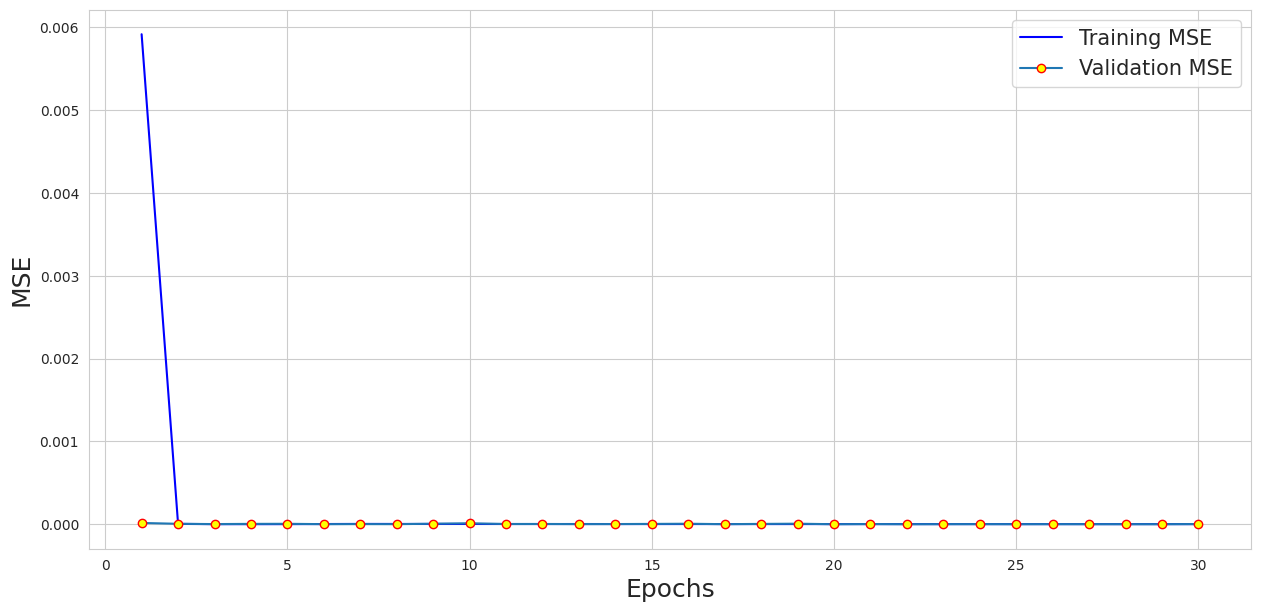

In [164]:
# Visualisations follow
# Detailed MSE graph
history_dict = history_4.history

mse_values= history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs,mse_values, 'b', label = 'Training MSE')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor = 'red', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MSE", size = 18)
plt.legend()
plt.show();

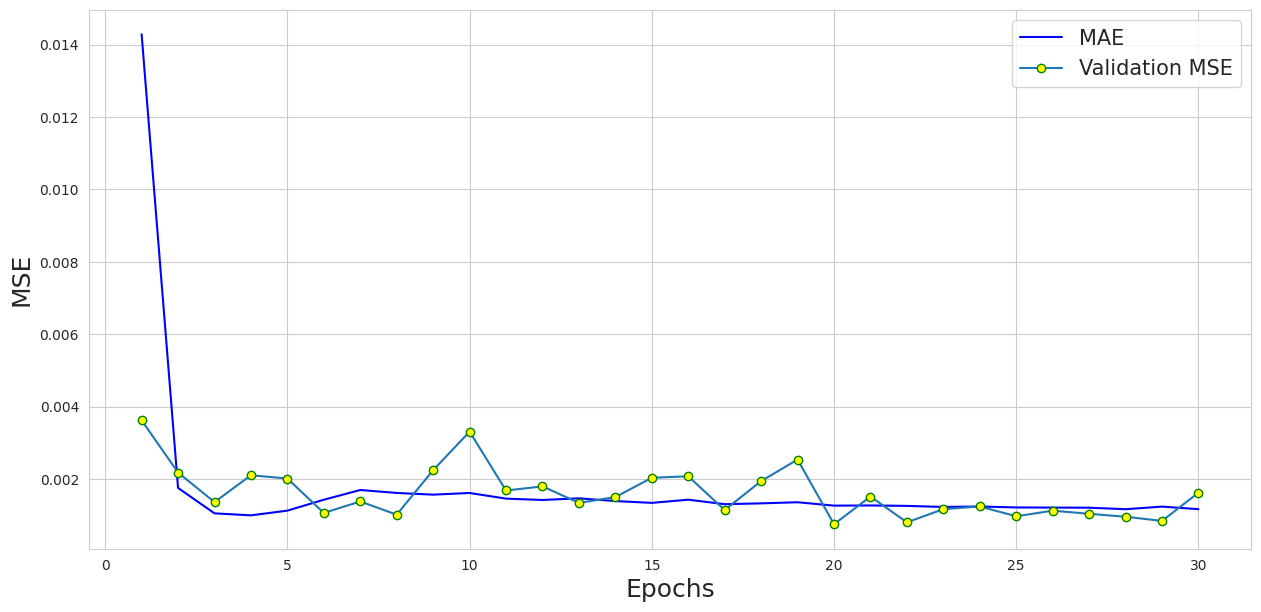

In [165]:
# Detailed MAE graph
history_dict = history_4.history

mae_values= history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs, mae_values, 'b', label = 'MAE')
plt.plot(epochs, val_mae_values, marker='o', markeredgecolor = 'green', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MSE", size = 18)
plt.legend()
plt.show();

In [166]:
# Predicting next 6 hours

In [167]:
pred = model_4(X_test)
pred

<tf.Tensor: shape=(4956, 2), dtype=float32, numpy=
array([[0.87117314, 0.8706544 ],
       [0.8711585 , 0.87055904],
       [0.87120247, 0.8705035 ],
       ...,
       [0.8651686 , 0.8635354 ],
       [0.86507046, 0.86359894],
       [0.8651637 , 0.8634264 ]], dtype=float32)>

In [168]:
len(pred)

4956

In [169]:
len(y_test)

4956

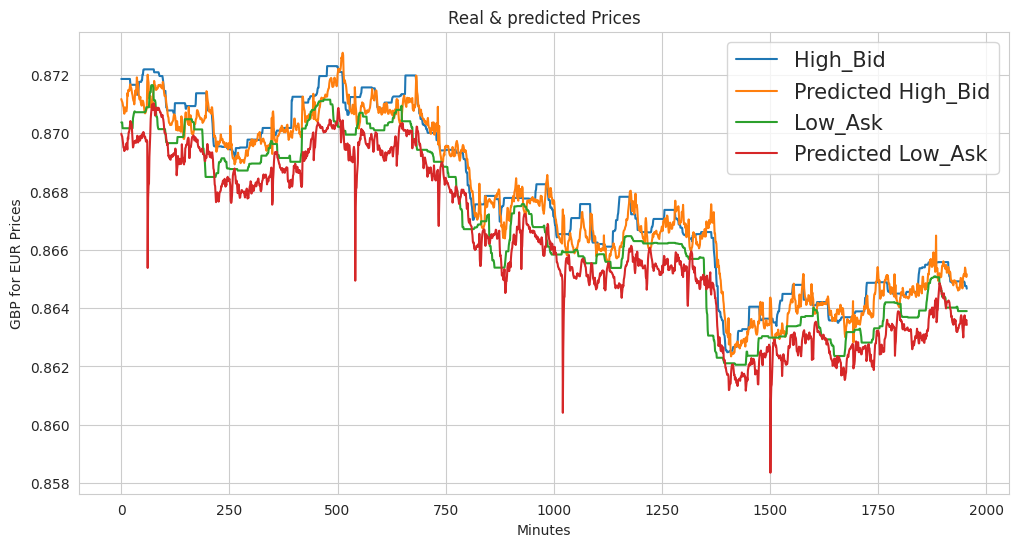

In [170]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)
line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')
line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & predicted Prices')
plt.ylabel('GBP for EUR Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

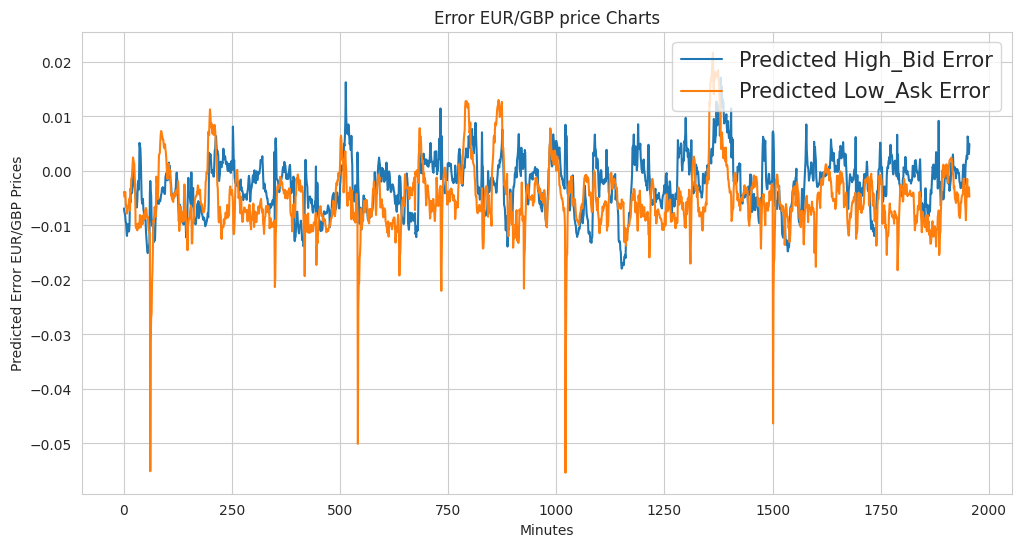

In [171]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)

a = (pred[N1:N2,0] - y_test[N1:N2,0])*10
b = (pred[N1:N2,1] - y_test[N1:N2,1])*10

line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error EUR/GBP price Charts')
plt.ylabel('Predicted Error EUR/GBP Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

## Model 5

### Training

In [221]:
model_5 = keras.Sequential([
    keras.layers.LSTM(100, activation='tanh', input_shape= (232, 18)),
    keras.layers.Dense(2)
])

model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100)            │        47,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,802 (186.73 KB)

 Trainable params: 47,802 (186.73 KB)

 Non-trainable params: 0 (0.00 B)

In [222]:
model_5.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

In [223]:
mc = ModelCheckpoint('model_5.keras', monitor = 'val_loss', mode ='min', verbose =1, save_best_only =True)

In [224]:
history_5 = model_5.fit(X_train, y_train, batch_size = BATCH_SIZE, epochs = EPOCHS,
                    validation_split = 0.2,
                    verbose = 1, callbacks = [es, mc])

Epoch 1/100
1113/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0238 - mae: 0.0440
Epoch 1: val_loss improved from None to 0.00008, saving model to model_5.keras

Epoch 1: finished saving model to model_5.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0038 - mae: 0.0124 - val_loss: 8.0756e-05 - val_mae: 0.0086
Epoch 2/100
1112/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6546e-05 - mae: 0.0032
Epoch 2: val_loss improved from 0.00008 to 0.00001, saving model to model_5.keras

Epoch 2: finished saving model to model_5.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 1.1164e-05 - mae: 0.0026 - val_loss: 5.6047e-06 - val_mae: 0.0020
Epoch 3/100
1111/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3023e-06 - mae: 0.0016
Epoch 3: val_loss improved from 0.00001 to 0.00000, saving model to model_5.keras

Epoch 3: finished saving model to model_5.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 3.8177e-06 - mae: 0.0015 - val_loss: 3.6231e-06 - val_mae: 0

In [225]:
model_5 = keras.models.load_model('model_5.keras')

### Evaluating

In [226]:
scores = model_5.evaluate(X_test, y_test, verbose= 1)
scores

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9949e-06 - mae: 0.0011


[1.994901595026022e-06, 0.0011113109067082405]

In [227]:
print("Mean squared error (MSE) %.9f" %(scores[0]))

Mean squared error (MSE) 0.000001995


In [228]:
print("Mean absolute error (MAE) %.9f " %(scores[1]))

Mean absolute error (MAE) 0.001111311 


In [229]:
scores_entry = {
    "MSE": scores[0],
    "MAE": scores[1],
}

MSE_MAE.append(scores_entry)

MSE_MAE_pd = pd.DataFrame(MSE_MAE)
MSE_MAE_pd

,MSE,MAE
0,7.196428e-07,0.000629
1,1.994902e-06,0.001111


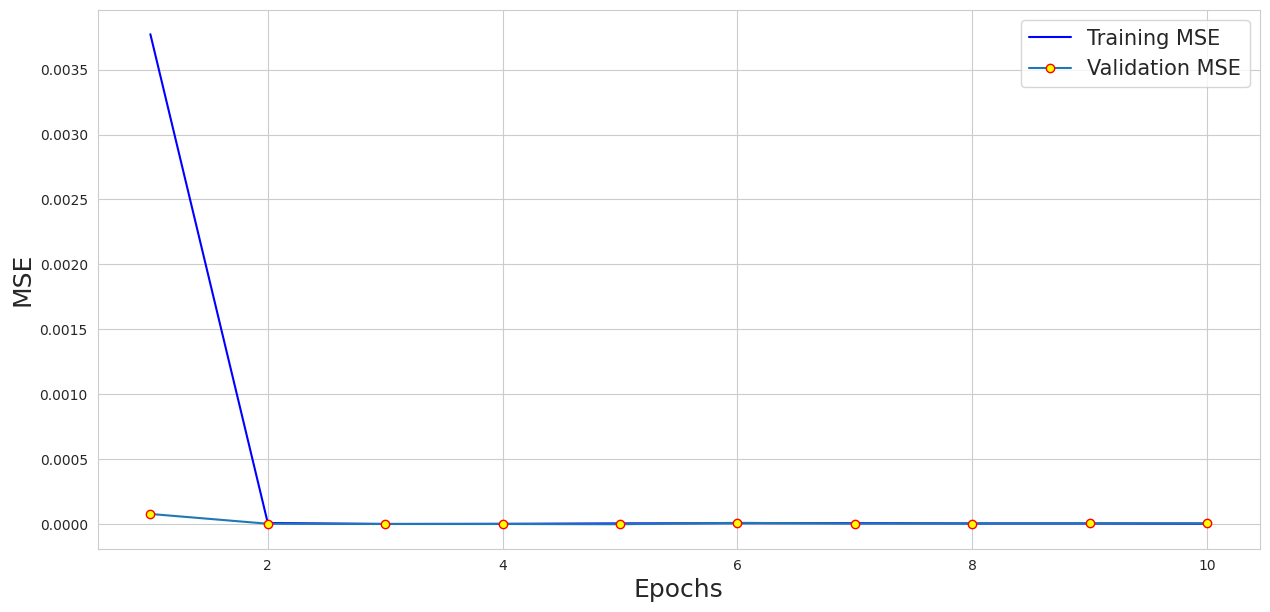

In [230]:
# Visualisations follow
# Detailed MSE graph
history_dict = history_5.history

mse_values= history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs,mse_values, 'b', label = 'Training MSE')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor = 'red', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MSE", size = 18)
plt.legend()
plt.show();

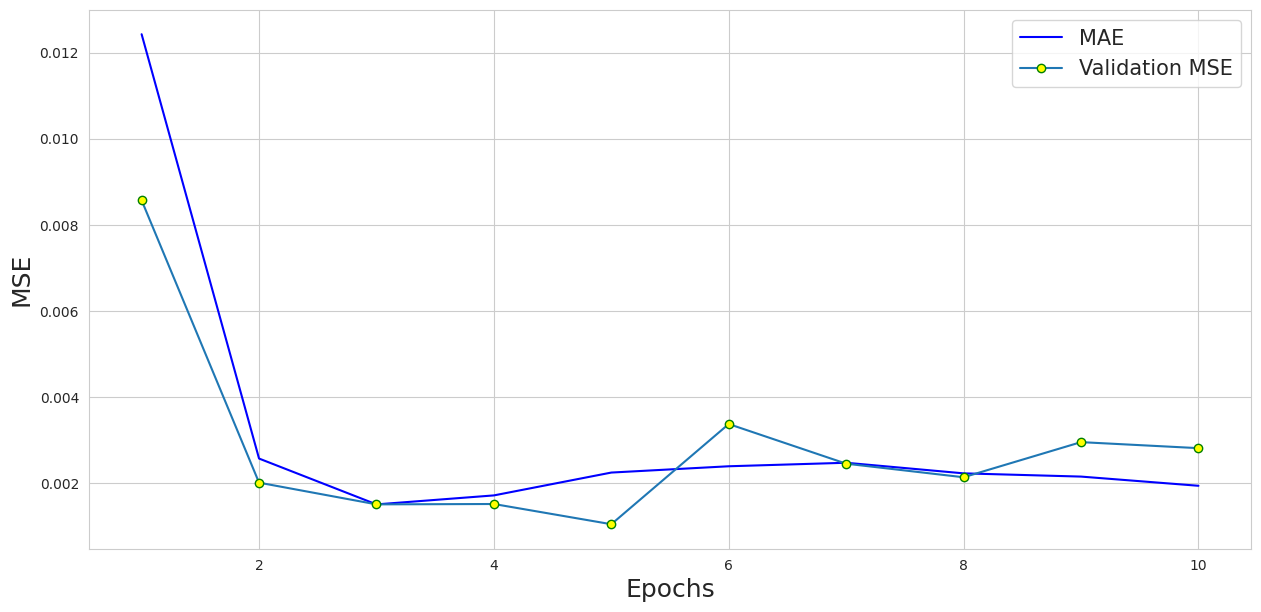

In [231]:
# Detailed MAE graph
history_dict = history_5.history

mae_values= history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs, mae_values, 'b', label = 'MAE')
plt.plot(epochs, val_mae_values, marker='o', markeredgecolor = 'green', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MAE", size = 18)
plt.legend()
plt.show();

In [183]:
# Predicting next 6 hours

In [232]:
pred = model_5(X_test)
pred

<tf.Tensor: shape=(4956, 2), dtype=float32, numpy=
array([[0.8726038 , 0.87002385],
       [0.87246174, 0.8700831 ],
       [0.8726759 , 0.8701363 ],
       ...,
       [0.8667838 , 0.86317575],
       [0.8667069 , 0.8631672 ],
       [0.86666757, 0.8631222 ]], dtype=float32)>

In [233]:
len(pred)

4956

In [234]:
len(y_test)

4956

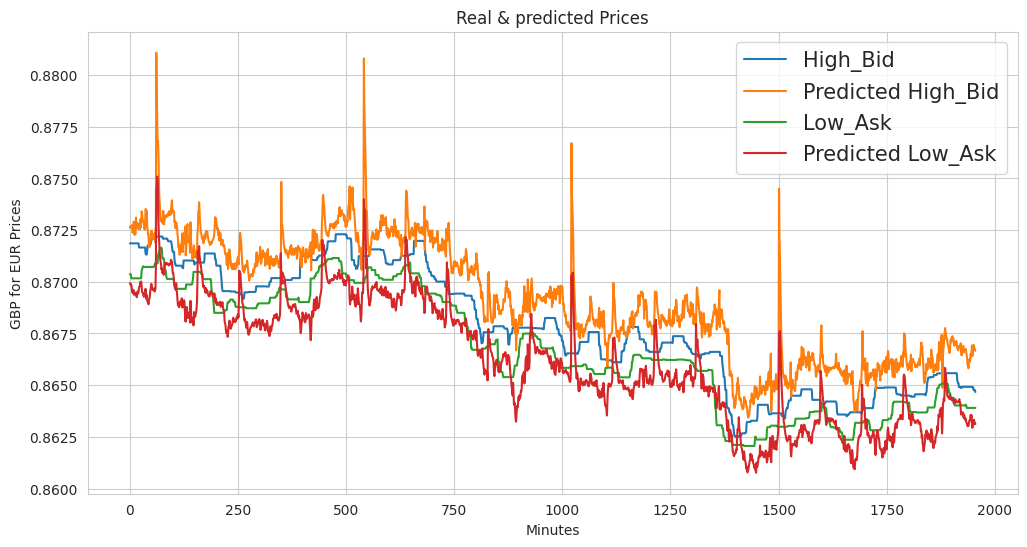

In [235]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)
line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')
line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & predicted Prices')
plt.ylabel('GBP for EUR Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

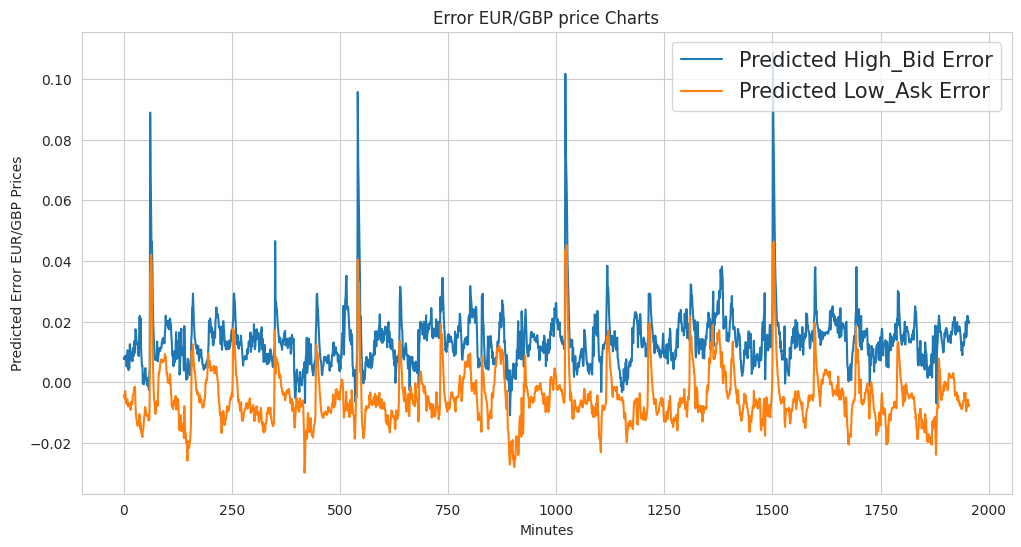

In [236]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)

a = (pred[N1:N2,0] - y_test[N1:N2,0])*10
b = (pred[N1:N2,1] - y_test[N1:N2,1])*10

line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error EUR/GBP price Charts')
plt.ylabel('Predicted Error EUR/GBP Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

## Model 6 Transformer

this model is based of "Timeseries classification with a Transformer model by Theodoros Ntakouris" (https://keras.io/examples/timeseries/timeseries_classification_transformer/)

### Training

In [189]:
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,):

    inputs = keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(2)(x)
    return keras.Model(inputs, outputs)

In [190]:
input_shape = X_train.shape[1:]

model_6 = build_model(
    input_shape,
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
)

model_6.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

mc = ModelCheckpoint('model_6.keras', monitor = 'val_loss', mode ='min', verbose =1, save_best_only =True)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 232, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 232, 18)   │     76,818 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 232, 18)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 232, 18)   │         36 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 232, 4)    │         76 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 232, 4)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 232, 18)   │         90 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 232, 18)   │     76,818 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 232, 18)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 232, 4)    │         76 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 232, 4)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 232, 18)   │         90 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 232, 18)   │         36 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 232, 18)   │          0 │ layer_normalizat… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 932,357 (3.56 MB)

 Trainable params: 310,785 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 621,572 (2.37 MB)

In [191]:
history_6 = model_6.fit(X_train, y_train, batch_size = BATCH_SIZE, epochs = EPOCHS,
                    validation_split = 0.2,
                    verbose = 1, callbacks = [es, mc])

Epoch 1/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1913 - mae: 0.2313
Epoch 1: val_loss improved from None to 0.00717, saving model to model_6.keras

Epoch 1: finished saving model to model_6.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 110s 79ms/step - loss: 0.0514 - mae: 0.1341 - val_loss: 0.0072 - val_mae: 0.0825
Epoch 2/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0099 - mae: 0.0786
Epoch 2: val_loss improved from 0.00717 to 0.00228, saving model to model_6.keras

Epoch 2: finished saving model to model_6.keras
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 72s 64ms/step - loss: 0.0080 - mae: 0.0706 - val_loss: 0.0023 - val_mae: 0.0474
Epoch 3/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0037 - mae: 0.0480
Epoch 3: val_loss did not improve from 0.00228
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 71s 63ms/step - loss: 0.0029 - mae: 0.0417 - val_loss: 0.0029 - val_mae: 0.0475
Epoch 4/100
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0011 - mae: 0.0255
Epoch 4: val_loss di

In [103]:
model_6 = keras.models.load_model('model_6.keras')

### Evaluating

In [104]:
scores = model_6.evaluate(X_test, y_test, verbose= 1)
scores

155/155 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0010 - mae: 0.0317


[0.0010146029526367784, 0.0316665917634964]

In [107]:
print("Mean squared error (MSE) %.9f" %(scores[0]))

Mean squared error (MSE) 0.001014603


In [108]:
print("Mean absolute error (MAE) %.9f " %(scores[1]))

Mean absolute error (MAE) 0.031666592 


In [36]:
scores_entry = {
    "MSE": scores[0],
    "MAE": scores[1],
}

MSE_MAE.append(scores_entry)

MSE_MAE_pd = pd.DataFrame(MSE_MAE)
MSE_MAE_pd

,MSE,MAE
0,7.196428e-07,0.000629
1,1.994902e-06,0.001111
2,1.014811e-03,0.031670


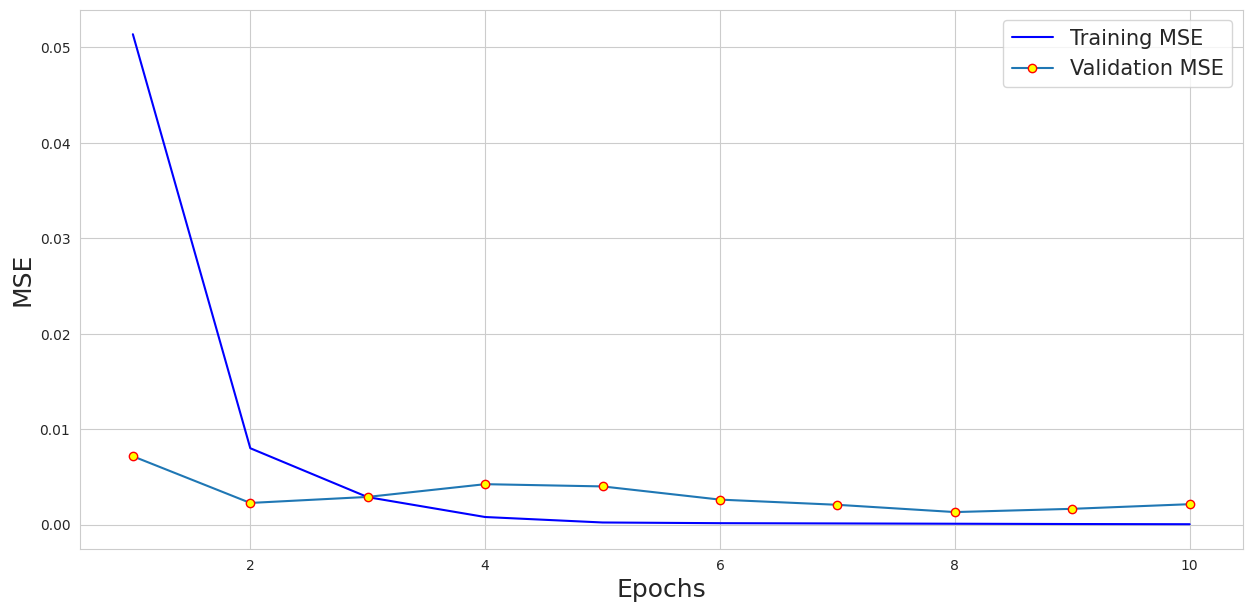

In [242]:
# Visualisations follow
# Detailed MSE graph
history_dict = history_6.history

mse_values= history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs,mse_values, 'b', label = 'Training MSE')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor = 'red', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MSE", size = 18)
plt.legend()
plt.show();

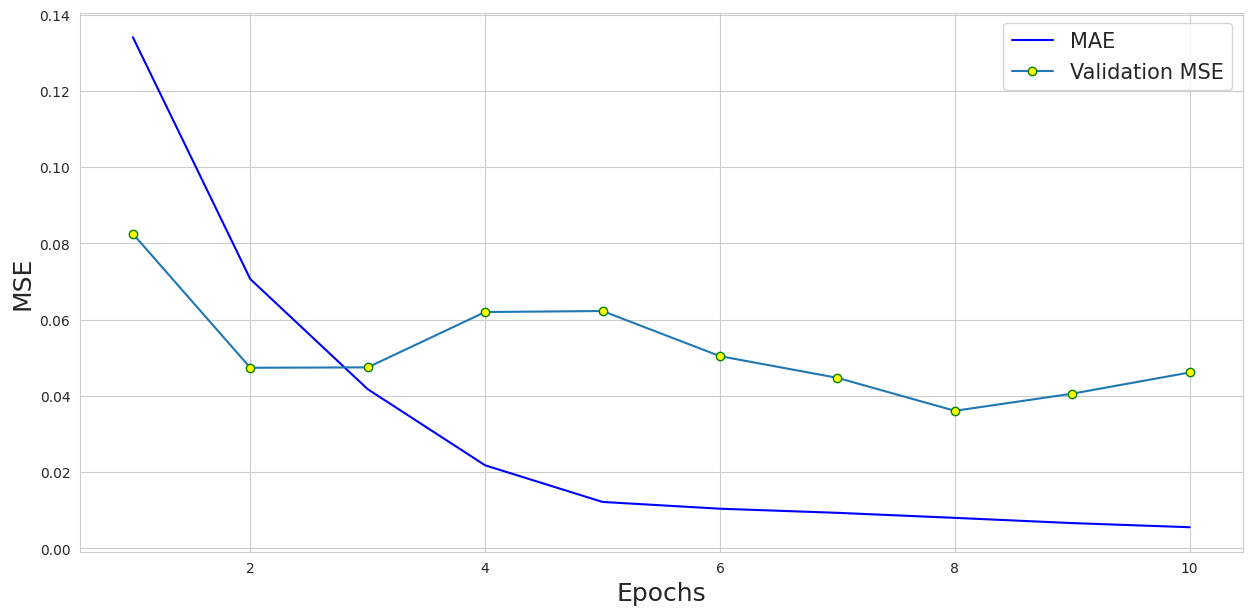

In [243]:
# Detailed MAE graph
history_dict = history_6.history

mae_values= history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)
plt.figure(num = 1, figsize =(15,7))
plt.plot(epochs, mae_values, 'b', label = 'MAE')
plt.plot(epochs, val_mae_values, marker='o', markeredgecolor = 'green', markerfacecolor = 'yellow', label= 'Validation MSE')
plt.xlabel("Epochs", size= 18)
plt.ylabel("MSE", size = 18)
plt.legend()
plt.show();

In [199]:
# Predicting next 6 hours

In [105]:
pred = model_6(X_test)
pred

<tf.Tensor: shape=(4956, 2), dtype=float32, numpy=
array([[0.8380207 , 0.83632916],
       [0.8380377 , 0.83634394],
       [0.8380749 , 0.8363764 ],
       ...,
       [0.8368408 , 0.83528143],
       [0.8368605 , 0.83529866],
       [0.83686215, 0.8353001 ]], dtype=float32)>

In [106]:
len(pred)

4956

In [107]:
len(y_test)

4956

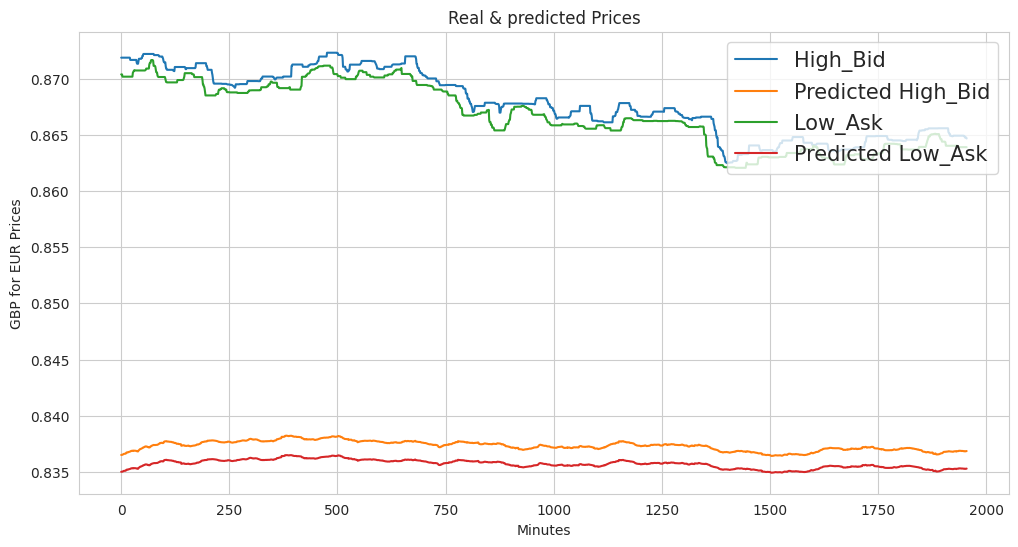

In [108]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)
line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')
line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & predicted Prices')
plt.ylabel('GBP for EUR Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

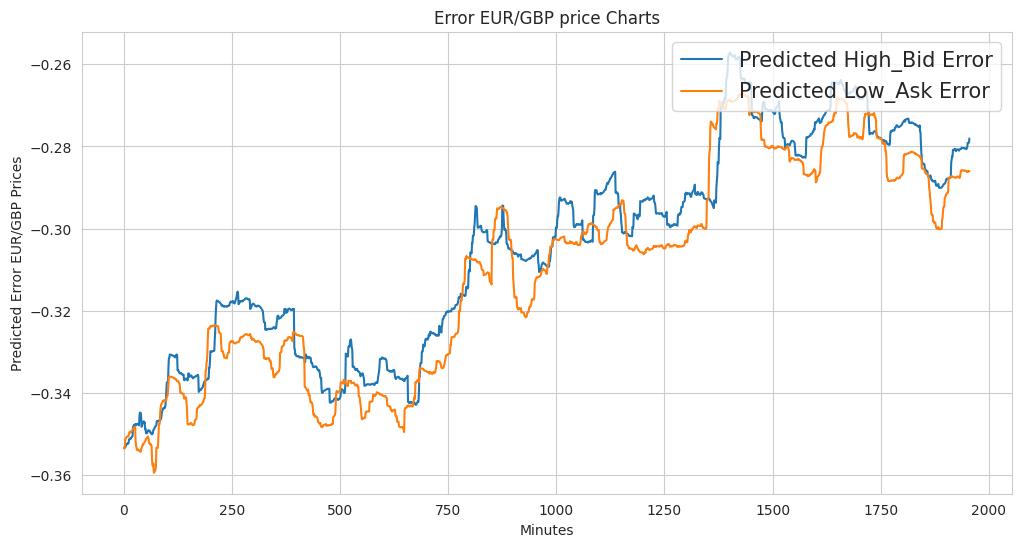

In [110]:
N1 = 3000
LL = 4956
N2 = N1+LL

plt.ion()
fig = plt.figure(figsize = (12,6))

ax1 = fig.add_subplot(111)

a = (pred[N1:N2,0] - y_test[N1:N2,0])*10
b = (pred[N1:N2,1] - y_test[N1:N2,1])*10

line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error EUR/GBP price Charts')
plt.ylabel('Predicted Error EUR/GBP Prices')
plt.xlabel('Minutes')
plt.legend(loc = 'upper right')
plt.show()

## Price prediction Model Comparision

In [245]:
MSE_MAE_pd.index = ["GRU Model", "LSTM Model", "Transformer"]
MSE_MAE_pd

,MSE,MAE
GRU Model,7.196428e-07,0.000629
LSTM Model,1.994902e-06,0.001111
Transformer,1.014811e-03,0.031670


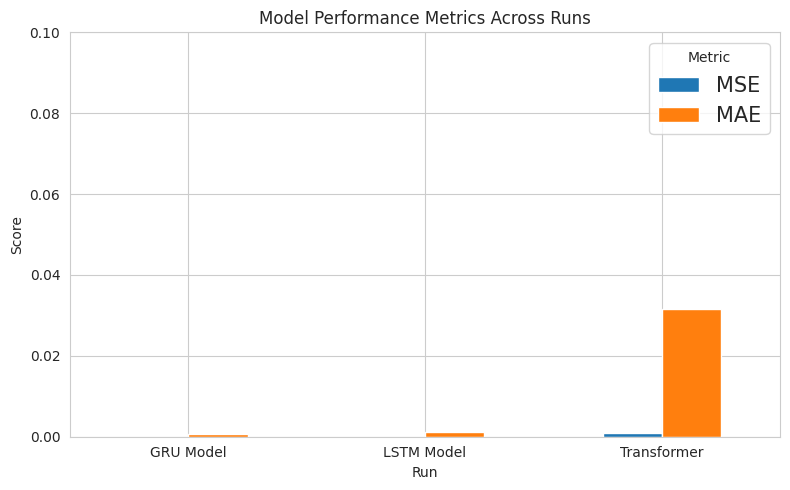

In [252]:
MSE_MAE_pd.plot(kind="bar", figsize=(8, 5))

plt.title("Model Performance Metrics Across Runs")
plt.xlabel("Run")
plt.ylabel("Score")
plt.ylim(0, 0.1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()S